# cNMF Program Comparison Across 5 TF Perturb-seq Benchmark Datasets

Notebook version of `benchmark_cnmf_comparison.py` (batch/SLURM entry point: `run_benchmark_cnmf_comparison.sh`). Uses the same `PALETTE` as `qc_comparison_5_datasets.ipynb` / `calibration_comparison_5_datasets.ipynb` for consistent dataset colors.

For each dataset: load gene spectra TPM + cell usages (Inference), cell->guide assignment (sceptre h5mu), perturbation-association log2FC + explained variance + GO/geneset/trait enrichment (Evaluation).

Then:
- Cosine-similarity program matching (Hungarian) — **C1**, **C2** (separate metric, not used for alignment elsewhere).
- Gene-identity overlap, defining the canonical "best match" (`match_programs_by_overlap`, top-300-gene Hungarian) used everywhere below — **C8**.
- Explained variance comparability — **C6**.
- TF-program log2FC (pipeline's own perturbation-association test), aligned by reciprocal best match — **C3**, **C4**.
- Cross-dataset correlation of that same log2FC profile — **C5**.
- Consistent-sign TF-program pairs annotated with cross-dataset-consistent enriched GO terms / genesets / GWAS traits, checked against WTC11/iPSC biology — **C7**.
- 3-panel paper figure (gene overlap, usage co-occurrence, conserved TF-program log2FC heatmap) — **Paper Figure A/B/C**.

Edit CONFIG to change `TF_OF_INTEREST`, the reference dataset (first entry in `DATASETS`), `k` (currently 30), or any other parameter.

In [30]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mudata
import scipy.sparse as sp
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from scipy.stats import hypergeom
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

sns.set_style("whitegrid")
%matplotlib inline

## Config

In [2]:
BASE_DIR = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets"
OUT_DIR  = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_cnmf_alex"
os.makedirs(OUT_DIR, exist_ok=True)

# Same palette as benchmark_cnmf_comparison.py / qc_comparison_5_datasets.ipynb /
# calibration_comparison_5_datasets.ipynb -- keeps dataset colors consistent across all figures.
PALETTE = {
    "CC-Perturb":        "#7030a0",
    "GEM-x v3 10xv3 5'": "#00b050",
    "HTv2 10xv3 5'":     "#ff4b3d",
    "HTO 10xv3 5'":      "#00b0f0",
    "10xv3 3'":          "#ebce9a",
}

# One entry per dataset. NOTE: FIRST entry = reference dataset (ref_name = dataset_names[0])
# that others are aligned to in C3/C4/C5/C7 -- reorder to change the reference.
# run_name: prefix before .gene_spectra_tpm.k_*.dt_*.txt. k: num programs. dt: threshold,
# underscores not dots ("0_2" not "0.2"). eval_subdir: "{k}_{eval_subdir}" folder under Evaluation.
DATASETS = [
    {
        "name":        "HTO 10xv3 5' (Hon)",
        "dir":         "Hon_WTC11-benchmark_TF-Perturb-seq",
        "run_name":    "070826_GaryHon_20iter_5KHVG_torch_halsvar_batch_e7",
        "k":           30,
        "dt":          "0_2",
        "eval_subdir": "0_2",
        "palette_key": "HTO 10xv3 5'",
    },
    {
        "name":        "CC-Perturb (Engreitz)",
        "dir":         "Engreitz_WTC11-benchmark_TF-Perturb-seq",
        "run_name":    "070826_Engreitz_20iter_5KHVG_torch_halsvar_batch_e7",
        "k":           30,
        "dt":          "0_2",
        "eval_subdir": "0_2",
        "palette_key": "CC-Perturb",
    },
    {
        "name":        "GEM-X v3 10xv3 5' (Gersbach)",
        "dir":         "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
        "run_name":    "070826_Gersbach_gemX_v3_20iter_5KHVG_torch_halsvar_batch_e7",
        "k":           30,
        "dt":          "0_2",
        "eval_subdir": "0_2",
        "palette_key": "GEM-x v3 10xv3 5'",
    },
    {
        "name":        "HTv2 10xv3 5' (Gersbach)",
        "dir":         "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
        "run_name":    "070826_Gersbach_HTV2_20iter_5KHVG_torch_halsvar_batch_e7",
        "k":           30,
        "dt":          "0_2",
        "eval_subdir": "0_2",
        "palette_key": "HTv2 10xv3 5'",
    },
    {
        "name":        "10xv3 3' (Huangfu)",
        "dir":         "Huangfu_WTC11-benchmark_TF-Perturb-seq",
        "run_name":    "070826_HuangFu_20iter_5KHVG_torch_halsvar_batch_e7",
        "k":           30,
        "dt":          "0_2",
        "eval_subdir": "0_2",
        "palette_key": "10xv3 3'",
    },
]

for ds in DATASETS:
    ds["color"] = PALETTE[ds["palette_key"]]
COLOR_MAP = {ds["name"]: ds["color"] for ds in DATASETS}
# Short technology-only label (no collaborator name in parens), for compact axis labels.
TECH_LABEL = {ds["name"]: ds["palette_key"] for ds in DATASETS}

# TF of interest for the per-TF usage plot (Figure C4).
# Must match gene_name values in the guide modality. Change this to explore different TFs.
TF_OF_INTEREST = "EZH2"

# Non-targeting label (used to compute baseline usage for normalization)
NON_TARGETING_LABEL = "non-targeting"

# Number of top genes to use for the cosine-similarity comparison in C1/C2 only
# (kept as a separate, complementary metric -- see N_TOP_GENES_OVERLAP for the
# canonical "best match" definition used everywhere else).
N_TOP_GENES_MATCH = 200

# Number of top genes (by weight) per program used for the gene-identity overlap.
# This is the notebook's canonical "best match" metric (see match_programs_by_overlap):
# used for C8, the paper-figure Panel A, and to align programs across datasets in
# C3/C4/C5/C7.
N_TOP_GENES_OVERLAP = 300

# Minimum number of cells required per TF perturbation to include it
MIN_CELLS_PER_TF = 10

## Helper functions

In [3]:
def load_cnmf_files(ds):
    """Load gene spectra TPM and usages for one dataset."""
    result_dir = os.path.join(BASE_DIR, ds["dir"], ds["run_name"], "Inference")
    k, dt, run = ds["k"], ds["dt"], ds["run_name"]

    tpm_path    = os.path.join(result_dir, f"Inference.gene_spectra_tpm.k_{k}.dt_{dt}.txt")
    usage_path  = os.path.join(result_dir, f"Inference.usages.k_{k}.dt_{dt}.consensus.txt")

    if not os.path.exists(tpm_path):
        raise FileNotFoundError(f"TPM file not found:\n  {tpm_path}")
    if not os.path.exists(usage_path):
        raise FileNotFoundError(f"Usage file not found:\n  {usage_path}")

    spectra = pd.read_csv(tpm_path, sep="\t", index_col=0)
    usages  = pd.read_csv(usage_path, sep="\t", index_col=0)

    print(f"  [{ds['name']}] spectra: {spectra.shape}  usages: {usages.shape}")
    return spectra, usages


def load_cell_guide_assignments(ds):
    """Load cell -> gene_name assignment from h5mu (Series: barcode -> gene_name)."""
    h5mu_path = os.path.join(BASE_DIR, ds["dir"], "sceptre",
                             "inference_mudata_cleaned.h5mu")
    if not os.path.exists(h5mu_path):
        h5mu_path = os.path.join(BASE_DIR, ds["dir"], "sceptre",
                             "inference_mudata.h5mu")

    print(f"  [{ds['name']}] loading h5mu (may take a moment)...")
    mdata = mudata.read_h5mu(h5mu_path, backed="r")

    guide_mod  = mdata["guide"]
    assignment = guide_mod.layers["guide_assignment"]   # cell x guide sparse
    gene_names = guide_mod.var["gene_name"].values       # per guide
    cell_bcs   = guide_mod.obs_names.tolist()

    # For each cell, find guides with assignment == 1
    # guide_assignment is typically a binary sparse matrix
    if sp.issparse(assignment):
        assignment = assignment.toarray()

    # Each cell gets the gene_name of its assigned guide(s).
    # If multiple guides assigned, take the first non-NT one;
    # if all NT or none, label as non-targeting / NA.
    assigned_tf = []
    for i in range(assignment.shape[0]):
        row      = assignment[i]
        hit_idx  = np.where(row > 0)[0]
        if len(hit_idx) == 0:
            assigned_tf.append(np.nan)
        else:
            names = [gene_names[j] for j in hit_idx]
            # Prefer non-targeting label if that's all there is
            non_nt = [n for n in names if n != NON_TARGETING_LABEL]
            if non_nt:
                assigned_tf.append(non_nt[0])
            else:
                assigned_tf.append(NON_TARGETING_LABEL)

    cell_tf = pd.Series(assigned_tf, index=cell_bcs, name="gene_name")

    mdata.file.close()
    print(f"  [{ds['name']}] {cell_tf.notna().sum()} / {len(cell_tf)} cells assigned")
    return cell_tf


def load_ensembl_symbol_map(ds):
    """Load ENSG -> gene symbol mapping from the Data directory."""
    csv_path = os.path.join(BASE_DIR, ds["dir"], "sceptre",
                            "ensembl_to_symbol.csv")
    if os.path.exists(csv_path):
        m = pd.read_csv(csv_path, index_col=0)
        # Expect columns: ensembl_id, gene_name (or similar)
        # Use the first column as key, second as value
        return dict(zip(m.index, m.iloc[:, 0]))
    return {}


def load_perturbation_associations(ds):
    """Combine per-batch "{k}_perturbation_association_results_{samp}.txt" files
    (one per categorical_key value), averaging log2FC across batches per (target_name, program_name)."""
    eval_dir = os.path.join(
        BASE_DIR, ds["dir"], ds["run_name"], "Evaluation", f"{ds['k']}_{ds['eval_subdir']}",
    )
    pattern = os.path.join(eval_dir, f"{ds['k']}_perturbation_association_results_*.txt")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No perturbation association files found matching:\n  {pattern}")

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep="\t")
        df["sample"] = os.path.basename(f)
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)

    agg = combined.groupby(["target_name", "program_name"], as_index=False)["log2FC"].mean()
    print(f"  [{ds['name']}] combined {len(files)} sample files "
          f"({combined.shape[0]} rows) -> {agg.shape[0]} unique target-program pairs")
    return agg

In [4]:
def match_programs(spectra_a, spectra_b, n_top=N_TOP_GENES_MATCH):
    """Hungarian-match programs B->A by cosine similarity on top-N genes by mean TPM weight.
    Returns sim_matrix (n_a x n_b), b_to_a (len n_b, matched A-index per B program), match_scores."""
    # Common genes
    common_genes = spectra_a.columns.intersection(spectra_b.columns)
    if len(common_genes) == 0:
        raise ValueError("No common genes between datasets for program matching.")

    a = spectra_a[common_genes].values   # programs_a x genes
    b = spectra_b[common_genes].values   # programs_b x genes

    # Restrict to top genes by mean weight across both datasets
    mean_weight = (a.mean(axis=0) + b.mean(axis=0)) / 2
    top_idx     = np.argsort(mean_weight)[::-1][:n_top]
    a_top = a[:, top_idx]
    b_top = b[:, top_idx]

    # Cosine similarity: 1 - cosine distance
    sim = 1 - cdist(a_top, b_top, metric="cosine")   # shape: (n_a, n_b)

    # Hungarian: maximise similarity -> minimise negative similarity
    row_ind, col_ind = linear_sum_assignment(-sim)

    # b_to_a[j] = which program in A is matched to program j in B
    b_to_a       = np.full(b.shape[0], -1, dtype=int)
    match_scores = np.full(b.shape[0], np.nan)
    for r, c in zip(row_ind, col_ind):
        b_to_a[c]       = r
        match_scores[c] = sim[r, c]

    return sim, b_to_a, match_scores


def compute_tf_program_usage(usages, cell_tf, min_cells=MIN_CELLS_PER_TF):
    """Mean program usage per TF (rows=TFs, cols=programs), for TFs with >= min_cells cells."""
    # Align cells: usages index vs cell_tf index
    common_cells = usages.index.intersection(cell_tf.index)
    if len(common_cells) == 0:
        # Try stripping dataset suffix from usage index (e.g. "_0")
        usage_stripped = usages.copy()
        usage_stripped.index = usage_stripped.index.str.rsplit("_", n=1).str[0]
        common_cells = usage_stripped.index.intersection(cell_tf.index)
        if len(common_cells) == 0:
            raise ValueError(
                "No overlapping cell barcodes between usages and h5mu.\n"
                f"  Usage index example:  {usages.index[:3].tolist()}\n"
                f"  Cell TF index example: {cell_tf.index[:3].tolist()}"
            )
        usages = usage_stripped

    u = usages.loc[common_cells]
    t = cell_tf.loc[common_cells]

    tf_usage = {}
    for tf, grp in t.groupby(t):
        if grp.shape[0] < min_cells:
            continue
        tf_usage[tf] = u.loc[grp.index].mean(axis=0).values

    result = pd.DataFrame(tf_usage, index=usages.columns).T   # TFs x programs
    return result


def program_name_to_idx(program_name, n_programs):
    """cNMF's Eval perturbation-association output numbers programs 1..k
    (matching the "P{i+1}" axis labels used throughout this notebook), so
    convert to a 0-indexed array position here rather than at each call site."""
    idx = int(program_name) - 1
    if not (0 <= idx < n_programs):
        raise ValueError(
            f"program_name={program_name!r} maps to index {idx}, outside "
            f"[0, {n_programs}) for n_programs={n_programs}. Check whether "
            f"program_name is really 1-indexed for this dataset's Eval output."
        )
    return idx


In [5]:
def load_explained_variance(ds):
    """Load per-program variance-explained values from the Evaluation output.
    Returns a Series indexed by 1-based program_name (int) -> VarianceExplained.
    """
    eval_dir = os.path.join(
        BASE_DIR, ds["dir"], ds["run_name"], "Evaluation", f"{ds['k']}_{ds['eval_subdir']}",
    )
    path = os.path.join(eval_dir, f"{ds['k']}_Explained_Variance.txt")
    df = pd.read_csv(path, sep="\t")
    return df.set_index("program_name")["VarianceExplained"]


def load_explained_variance_summary(ds):
    """Load the one-row Sum/Median/Max/Total explained-variance summary."""
    eval_dir = os.path.join(
        BASE_DIR, ds["dir"], ds["run_name"], "Evaluation", f"{ds['k']}_{ds['eval_subdir']}",
    )
    path = os.path.join(eval_dir, f"{ds['k']}_Explained_Variance_Summary.txt")
    df = pd.read_csv(path, sep="\t")
    return df.iloc[0]


# File-name suffix for each enrichment flavor, keyed by the short name used elsewhere in this notebook.
ENRICHMENT_KINDS = {
    "geneset": "geneset_enrichment",
    "GO_term": "GO_term_enrichment",
    "trait":   "trait_enrichment",
}


def load_enrichment(ds, kind):
    """Load one of the three per-program enrichment tables ('geneset', 'GO_term', or 'trait').
    Returns the raw long-format DataFrame (one row per enriched term per program)
    with columns: program_name, Term, P-value, Adjusted P-value, Odds Ratio,
    Combined Score, Genes, overlap_numerator, overlap_denominator.
    """
    eval_dir = os.path.join(
        BASE_DIR, ds["dir"], ds["run_name"], "Evaluation", f"{ds['k']}_{ds['eval_subdir']}",
    )
    path = os.path.join(eval_dir, f"{ds['k']}_{ENRICHMENT_KINDS[kind]}.txt")
    return pd.read_csv(path, sep="\t")


def top_terms(enrich_df, program_name, n=3, p_col="Adjusted P-value"):
    """Top-n enriched terms for one program (1-indexed program_name), ranked by adjusted p-value."""
    sub = enrich_df.loc[enrich_df["program_name"] == program_name].sort_values(p_col)
    return sub["Term"].head(n).tolist()

In [6]:
def native_program_name(ref_program_name, ds_name, ref_name, ds_mappings):
    """Translate a program number in ref_name's frame to the equivalent native
    program_name in ds_name (used to index that dataset's own Eval outputs).
    Returns None if ref_program_name has no match in ds_name (shouldn't happen
    with the Hungarian assignment, since every program gets matched, but the
    match can point at a program with 0 rows in that dataset's enrichment file
    in edge cases, which callers should handle by getting empty term lists).
    """
    if ds_name == ref_name:
        return ref_program_name
    a_to_b = {a: b for b, a in enumerate(ds_mappings[ds_name])}
    b_idx = a_to_b.get(ref_program_name - 1)
    return None if b_idx is None else b_idx + 1


def consistent_top_terms(enrich_dict, ref_program_name, dataset_names, ref_name, ds_mappings,
                          n_per_dataset=5, min_datasets=2):
    """For a program (numbered in ref_name's frame), pull each dataset's top
    n_per_dataset enriched terms for the matched program, then rank terms by
    how many distinct datasets they show up in. Returns [(term, n_datasets), ...],
    most-consistent first, restricted to terms appearing in >= min_datasets.
    """
    from collections import Counter
    term_datasets = Counter()
    for ds_name in dataset_names:
        native_p = native_program_name(ref_program_name, ds_name, ref_name, ds_mappings)
        if native_p is None:
            continue
        for t in set(top_terms(enrich_dict[ds_name], native_p, n=n_per_dataset)):
            term_datasets[t] += 1
    return [(t, c) for t, c in term_datasets.most_common() if c >= min_datasets]

In [7]:
def top_gene_sets(spectra, n_top=N_TOP_GENES_OVERLAP):
    """For each program (row) in spectra, the set of its top-n_top genes by weight."""
    return [
        set(spectra.columns[np.argsort(spectra.loc[p].values)[::-1][:n_top]])
        for p in spectra.index
    ]


def gene_overlap_matrix(spectra_a, spectra_b, n_top=N_TOP_GENES_OVERLAP):
    """Pairwise size of the top-n_top gene-set intersection between two datasets'
    programs (raw shared-gene count, 0..n_top).
    """
    sets_a = top_gene_sets(spectra_a, n_top)
    sets_b = top_gene_sets(spectra_b, n_top)
    mat = np.zeros((len(sets_a), len(sets_b)), dtype=int)
    for i, sa in enumerate(sets_a):
        for j, sb in enumerate(sets_b):
            mat[i, j] = len(sa & sb)
    return mat


def match_programs_by_overlap(spectra_a, spectra_b, n_top=N_TOP_GENES_OVERLAP):
    """The notebook's canonical 'best match' program pair definition: Hungarian
    assignment maximizing total shared top-n_top-gene count (see gene_overlap_matrix),
    NOT cosine similarity on weighted genes. Used to align programs across datasets
    everywhere except C1/C2, which are specifically about the cosine-similarity metric.
    Returns:
      overlap_matrix : (n_programs_a x n_programs_b) shared-gene-count matrix
      b_to_a         : array of length n_programs_b giving matched program in A
      match_scores   : shared-gene count for each matched pair
    """
    mat = gene_overlap_matrix(spectra_a, spectra_b, n_top=n_top)
    row_ind, col_ind = linear_sum_assignment(-mat)
    b_to_a       = np.full(mat.shape[1], -1, dtype=int)
    match_scores = np.full(mat.shape[1], np.nan)
    for r, c in zip(row_ind, col_ind):
        b_to_a[c]       = r
        match_scores[c] = mat[r, c]
    return mat, b_to_a, match_scores

## Load all datasets

In [8]:
# dataset_name -> {spectra (programs x genes), usages (cells x programs), cell_tf (Series),
# tf_usage (TFs x programs), ensg_map, assoc (TF-program log2FC), var (VarianceExplained
# Series), var_summary (Sum/Median/Max/Total), geneset/go/trait (enrichment, long format)}
all_spectra, all_usages, all_cell_tf, all_tf_usage   = {}, {}, {}, {}
all_ensg_map, all_assoc, all_var, all_var_summary    = {}, {}, {}, {}
all_geneset, all_go, all_trait                       = {}, {}, {}

for ds in DATASETS:
    print(f"\nLoading {ds['name']}...")
    spectra, usages = load_cnmf_files(ds)
    cell_tf         = load_cell_guide_assignments(ds)
    ensg_map        = load_ensembl_symbol_map(ds)
    assoc           = load_perturbation_associations(ds)
    var_explained   = load_explained_variance(ds)
    var_summary     = load_explained_variance_summary(ds)
    geneset_enrich  = load_enrichment(ds, "geneset")
    go_enrich       = load_enrichment(ds, "GO_term")
    trait_enrich    = load_enrichment(ds, "trait")

    all_spectra[ds["name"]]     = spectra
    all_usages[ds["name"]]      = usages
    all_cell_tf[ds["name"]]     = cell_tf
    all_ensg_map[ds["name"]]    = ensg_map
    all_assoc[ds["name"]]       = assoc
    all_var[ds["name"]]         = var_explained
    all_var_summary[ds["name"]] = var_summary
    all_geneset[ds["name"]]     = geneset_enrich
    all_go[ds["name"]]          = go_enrich
    all_trait[ds["name"]]       = trait_enrich

    tf_usage = compute_tf_program_usage(usages, cell_tf)
    all_tf_usage[ds["name"]] = tf_usage

    print(f"  [{ds['name']}] TF-program matrix: {tf_usage.shape}")
    print(f"  TFs included: {sorted(tf_usage.index.tolist())}")
    print(f"  [{ds['name']}] explained variance: sum={var_summary['Sum']:.4f}  "
          f"median={var_summary['Median']:.4f}  max={var_summary['Max']:.4f}")
    print(f"  [{ds['name']}] enrichment terms: geneset={len(geneset_enrich)}  "
          f"GO_term={len(go_enrich)}  trait={len(trait_enrich)}")

dataset_names = list(all_spectra.keys())
n_datasets    = len(dataset_names)
print(f"\nLoaded {n_datasets} datasets.")


Loading HTO 10xv3 5' (Hon)...
  [HTO 10xv3 5' (Hon)] spectra: (30, 9479)  usages: (60817, 30)
  [HTO 10xv3 5' (Hon)] loading h5mu (may take a moment)...
  [HTO 10xv3 5' (Hon)] 60523 / 60817 cells assigned
  [HTO 10xv3 5' (Hon)] combined 1 sample files (1800 rows) -> 1800 unique target-program pairs
  [HTO 10xv3 5' (Hon)] TF-program matrix: (61, 30)
  TFs included: ['AFF4', 'ARID1A', 'ARID1B', 'ARNT', 'BATF', 'BMAL1', 'CD151', 'CD55', 'CD81', 'CLOCK', 'CREBBP', 'CTNNB1', 'EED', 'EP300', 'ESRRB', 'EZH2', 'HDAC1', 'HIF1A', 'HMGA2', 'JARID2', 'KLF4', 'KLF6', 'LEF1', 'MYC', 'NANOG', 'NFIB', 'NGFRAP1', 'OR10J3', 'OR2A25', 'OR2AG2', 'OR2D3', 'OR2F1', 'OR4D6', 'OR4X1', 'OR6A2', 'OR6T1', 'PAX5', 'POU5F1', 'REST', 'RUNX1', 'SALL4', 'SMAD3', 'SMAD4', 'SMARCA2', 'SMARCA4', 'SMARCB1', 'SMARCC1', 'SMARCC2', 'SMARCD1', 'SMARCD2', 'SMARCD3', 'SOX2', 'SUZ12', 'TBX3', 'TCF12', 'TCF7', 'TCF7L1', 'TCF7L2', 'TFCP2L1', 'TFRC', 'non-targeting']
  [HTO 10xv3 5' (Hon)] explained variance: sum=0.0248  median=0

## Figure C1: Program-Program Cosine Similarity Between Datasets
One panel per dataset pair; diagonal-heavy = well-matched programs. Wrapped into a grid since 5 datasets gives 10 pairs.

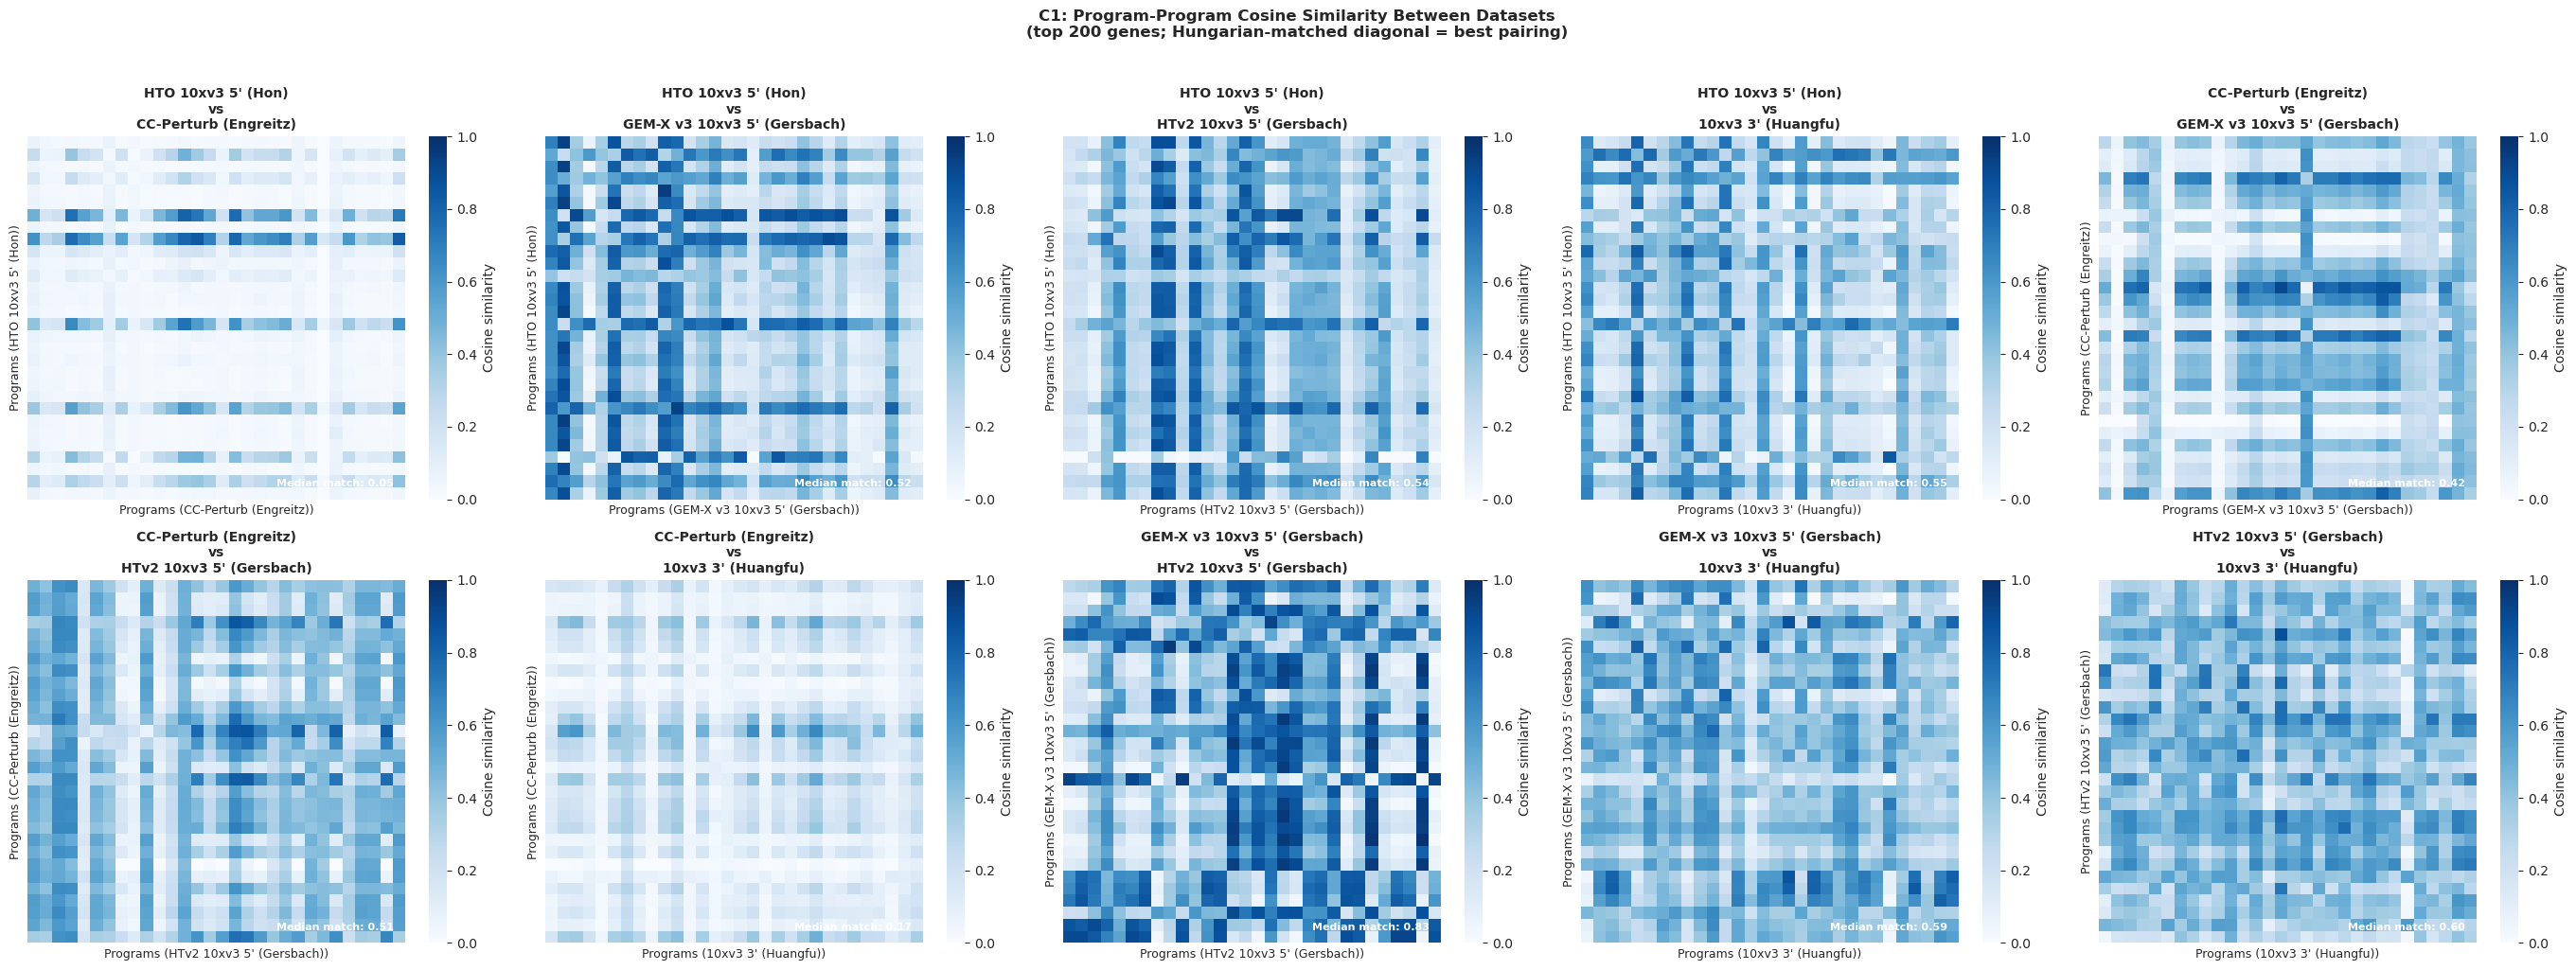

Figure C1 saved.


In [9]:
if n_datasets >= 2:
    n_pairs = n_datasets * (n_datasets - 1) // 2
    n_cols  = min(5, n_pairs)
    n_rows  = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5.5 * n_cols, 5 * n_rows),
                             squeeze=False)
    ax_idx = 0

    for i in range(n_datasets):
        for j in range(i + 1, n_datasets):
            ds_a = dataset_names[i]
            ds_b = dataset_names[j]

            sim, b_to_a, scores = match_programs(all_spectra[ds_a], all_spectra[ds_b])

            ax = axes[ax_idx // n_cols, ax_idx % n_cols]
            sns.heatmap(
                sim, ax=ax, cmap="Blues", vmin=0, vmax=1,
                xticklabels=False, yticklabels=False,
                cbar_kws={"label": "Cosine similarity"},
            )
            ax.set_title(f"{ds_a}\nvs\n{ds_b}", fontsize=10, fontweight="bold")
            ax.set_xlabel(f"Programs ({ds_b})", fontsize=9)
            ax.set_ylabel(f"Programs ({ds_a})", fontsize=9)

            ax.text(0.97, 0.03, f"Median match: {np.nanmedian(scores):.2f}",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=8, color="white", fontweight="bold")
            ax_idx += 1

    for empty_idx in range(ax_idx, n_rows * n_cols):
        axes[empty_idx // n_cols, empty_idx % n_cols].axis("off")

    fig.suptitle("C1: Program-Program Cosine Similarity Between Datasets\n"
                 f"(top {N_TOP_GENES_MATCH} genes; Hungarian-matched diagonal = best pairing)",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "C1_program_similarity_heatmap.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure C1 saved.")
else:
    print("Only one dataset loaded - skipping C1 (needs >= 2 datasets).")

## Figure C2: Matched Program Match-Score Distribution
Violin of cosine similarity scores for all matched pairs across dataset pairs. Higher = programs are more reproducible.

/tmp/ipykernel_1938859/3353390156.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=score_df, x="pair", y="score", palette="Blues", inner="box", ax=ax)


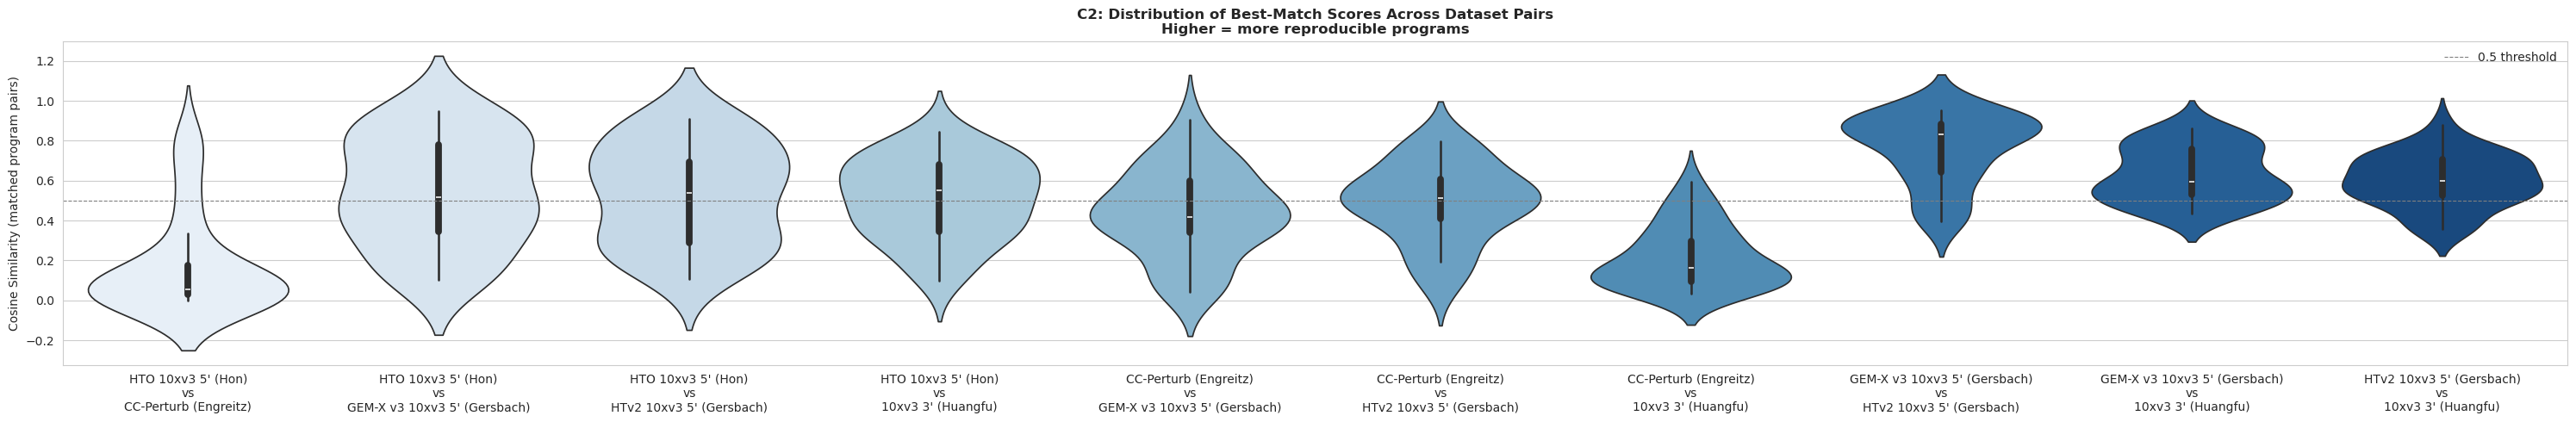

Figure C2 saved.


In [10]:
if n_datasets >= 2:
    score_records = []
    for i in range(n_datasets):
        for j in range(i + 1, n_datasets):
            ds_a, ds_b = dataset_names[i], dataset_names[j]
            _, _, scores = match_programs(all_spectra[ds_a], all_spectra[ds_b])
            for s in scores:
                if not np.isnan(s):
                    score_records.append({"pair": f"{ds_a}\nvs\n{ds_b}", "score": s})

    score_df = pd.DataFrame(score_records)

    fig, ax = plt.subplots(figsize=(max(5, 3 * score_df["pair"].nunique()), 5))
    sns.violinplot(data=score_df, x="pair", y="score", palette="Blues", inner="box", ax=ax)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="0.5 threshold")
    ax.set_xlabel(None)
    ax.set_ylabel("Cosine Similarity (matched program pairs)")
    ax.set_title("C2: Distribution of Best-Match Scores Across Dataset Pairs\n"
                 "Higher = more reproducible programs", fontweight="bold")
    ax.legend(frameon=False)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "C2_match_score_distribution.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure C2 saved.")

## Figure C8: Dataset-by-Dataset Top-300-Gene Overlap
Same layout as C1, but color scale = raw shared-gene count among each program's top-`N_TOP_GENES_OVERLAP` genes (0..`N_TOP_GENES_OVERLAP`), not a normalized score. Reordered so the reciprocal best match (Hungarian, max shared-gene count) sits on the diagonal. Populates `gene_overlap_mats` and defines `match_programs_by_overlap` — the canonical matching used to align C3/C4/C5/C7; C1/C2 stay on cosine similarity as a separate metric.

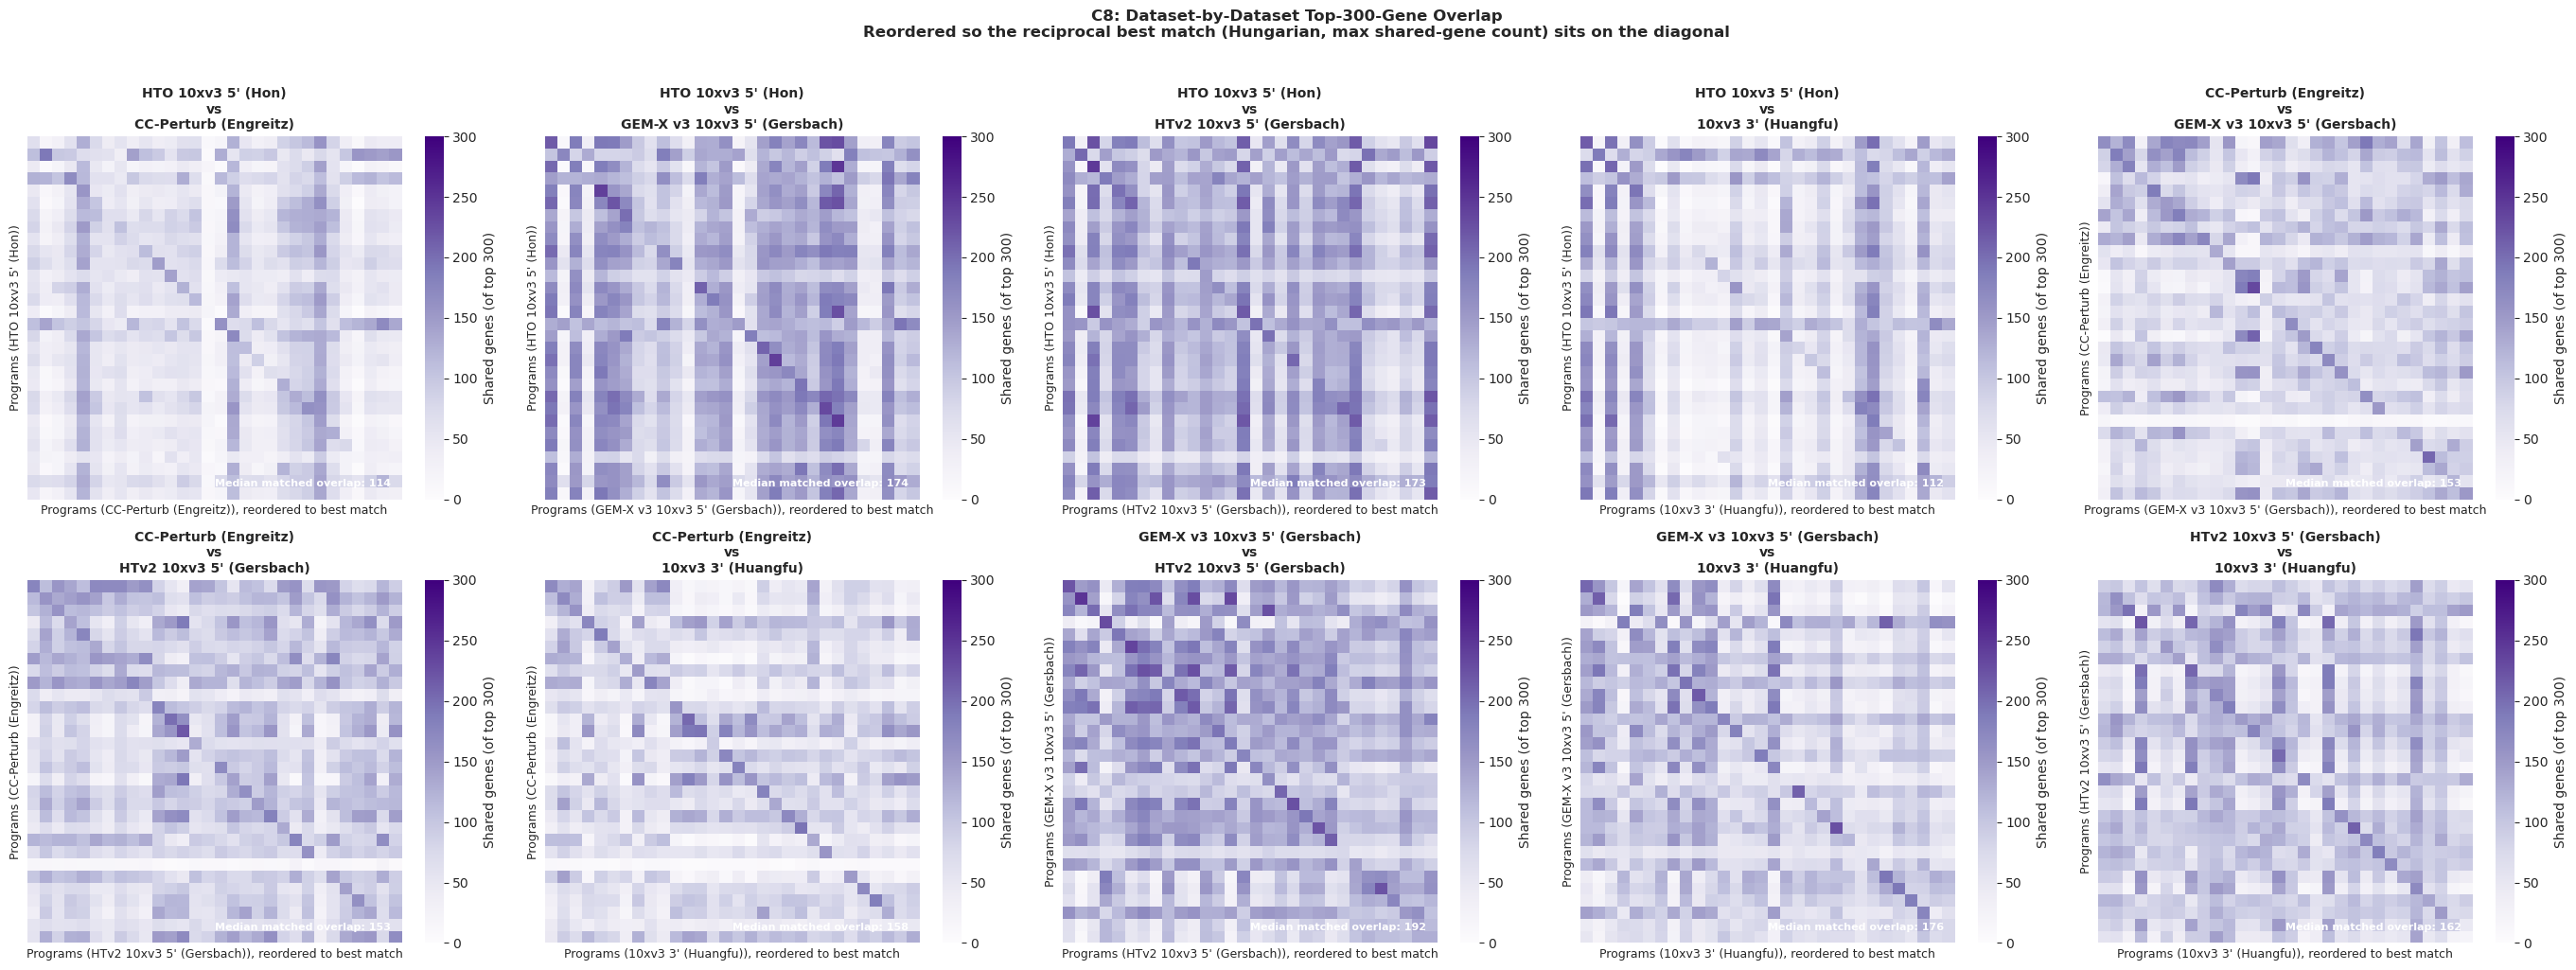

Figure C8 saved. Computed overlap matrices for 10 dataset pairs.


In [11]:
gene_overlap_mats = {}   # (ds_a, ds_b) -> shared-gene-count matrix, Hungarian-diagonal-reordered

if n_datasets >= 2:
    n_pairs = n_datasets * (n_datasets - 1) // 2
    n_cols  = min(5, n_pairs)
    n_rows  = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5.5 * n_cols, 5 * n_rows),
                             squeeze=False)
    ax_idx = 0

    for i in range(n_datasets):
        for j in range(i + 1, n_datasets):
            ds_a = dataset_names[i]
            ds_b = dataset_names[j]

            mat, b_to_a, _ = match_programs_by_overlap(all_spectra[ds_a], all_spectra[ds_b])
            order = np.argsort(b_to_a)   # puts the Hungarian-best-matched pair on the diagonal
            mat = mat[:, order]
            gene_overlap_mats[(ds_a, ds_b)] = mat

            ax = axes[ax_idx // n_cols, ax_idx % n_cols]
            sns.heatmap(
                mat, ax=ax, cmap="Purples", vmin=0, vmax=N_TOP_GENES_OVERLAP,
                xticklabels=False, yticklabels=False,
                cbar_kws={"label": f"Shared genes (of top {N_TOP_GENES_OVERLAP})"},
            )
            ax.set_title(f"{ds_a}\nvs\n{ds_b}", fontsize=10, fontweight="bold")
            ax.set_xlabel(f"Programs ({ds_b}), reordered to best match", fontsize=9)
            ax.set_ylabel(f"Programs ({ds_a})", fontsize=9)

            ax.text(0.97, 0.03, f"Median matched overlap: {int(np.median(np.diag(mat)))}",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=8, color="white", fontweight="bold")
            ax_idx += 1

    for empty_idx in range(ax_idx, n_rows * n_cols):
        axes[empty_idx // n_cols, empty_idx % n_cols].axis("off")

    fig.suptitle(f"C8: Dataset-by-Dataset Top-{N_TOP_GENES_OVERLAP}-Gene Overlap\n"
                 "Reordered so the reciprocal best match (Hungarian, max shared-gene count) sits on the diagonal",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "C8_gene_overlap_heatmap.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure C8 saved. Computed overlap matrices for {len(gene_overlap_mats)} dataset pairs.")
else:
    print("Only one dataset loaded - skipping C8 (needs >= 2 datasets).")

## Figure C9 and C10: Heatmap and boxplot based on HG significance test

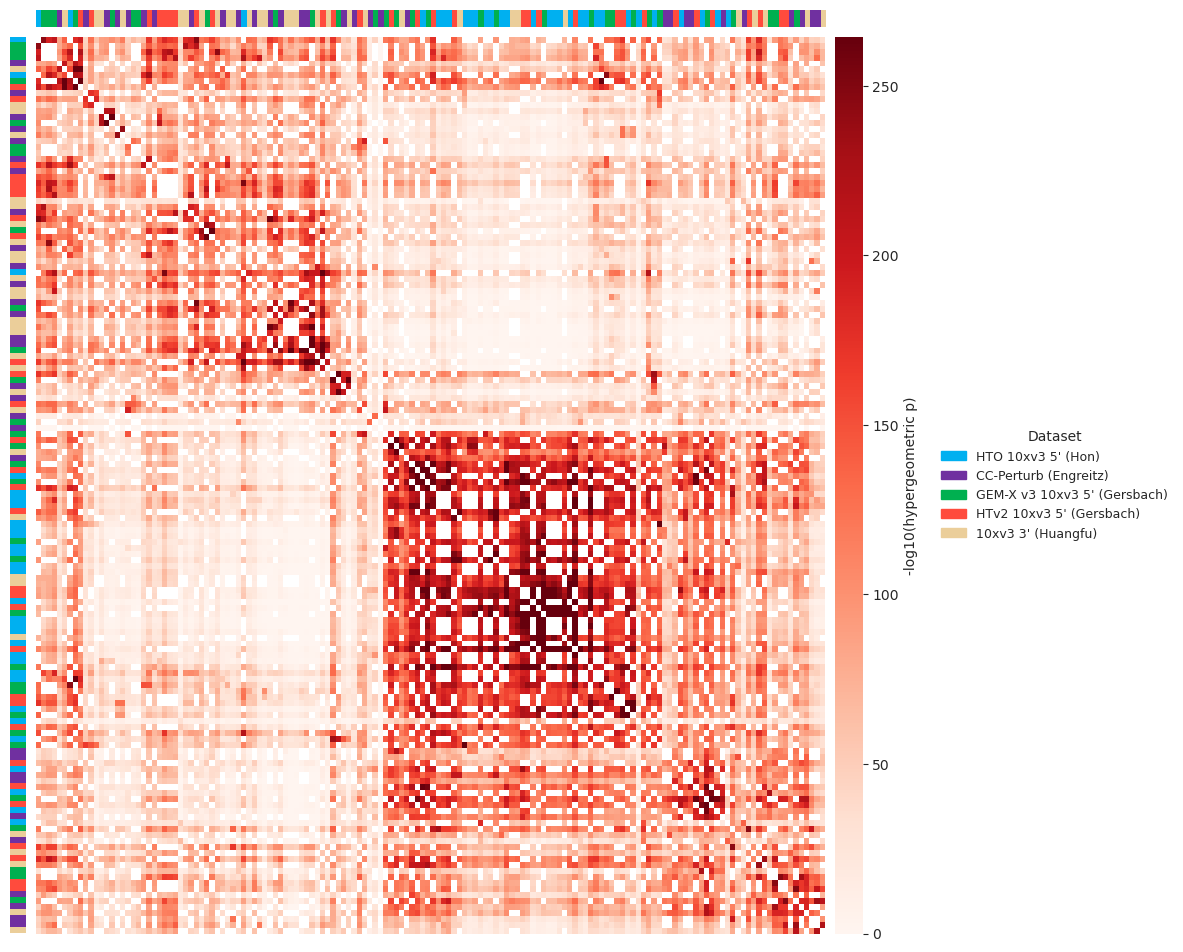

Figure C9 saved.


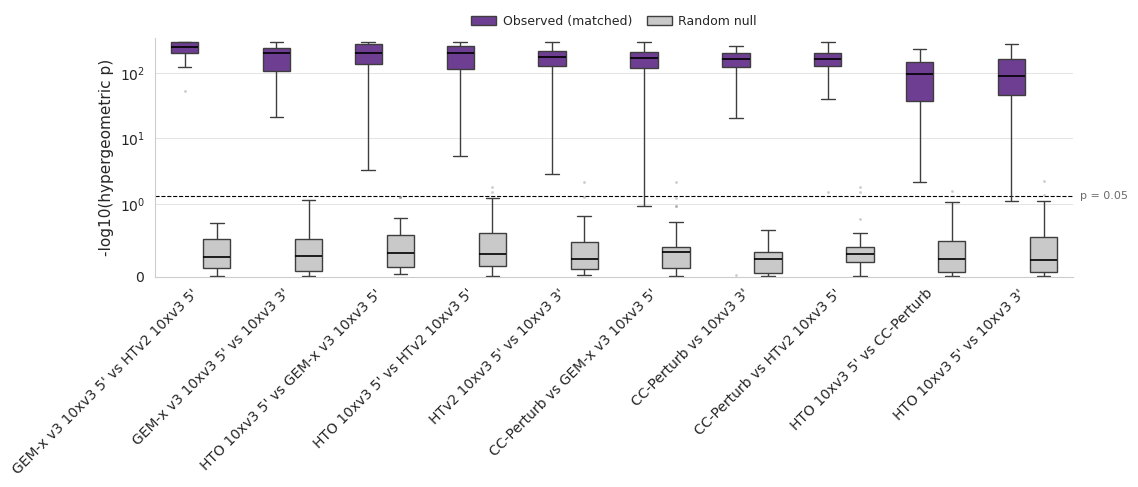

Figure C10 (Hungarian matching) saved.


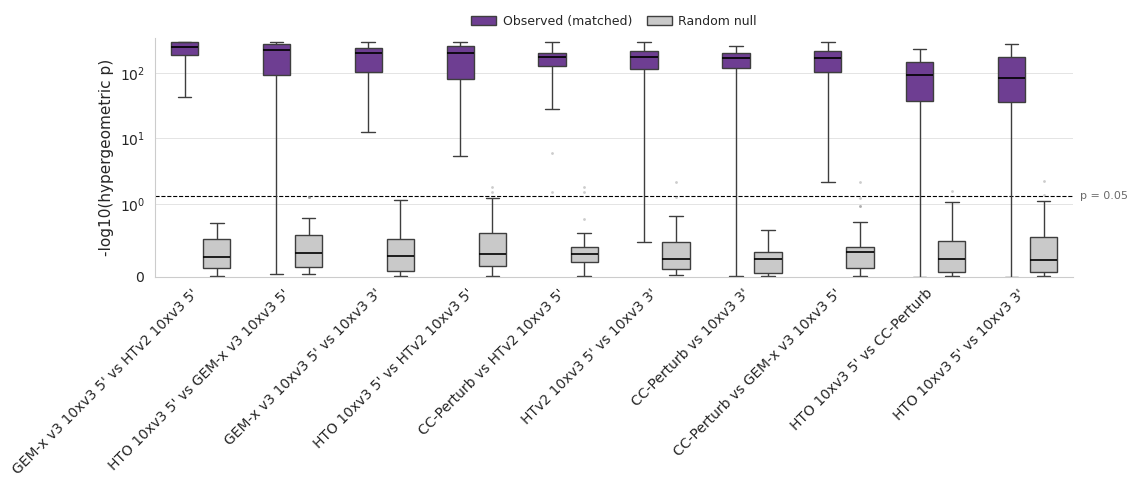

Figure C10 (Greedy matching) saved.


/tmp/ipykernel_1938859/2881871189.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


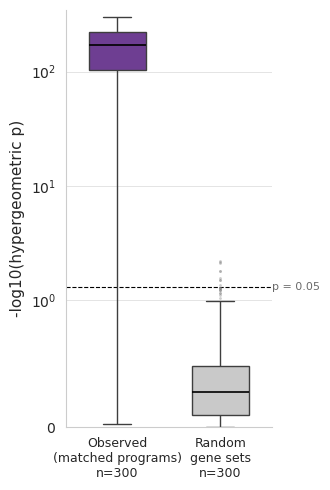

Figure C11 (Hungarian matching) saved.


/tmp/ipykernel_1938859/2881871189.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


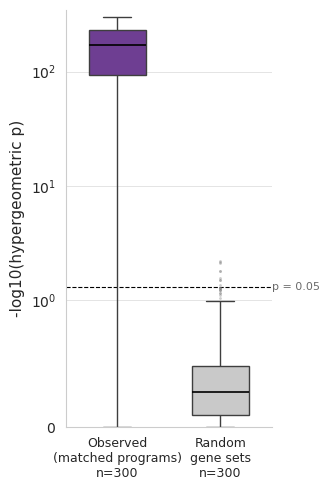

Figure C11 (Greedy matching) saved.


In [32]:
def hypergeom_overlap_pvalue(k, n_top, M):
    """One-sided hypergeometric p-value: P(overlap >= k) for two independent
    size-n_top gene sets drawn without replacement from a population of size M.
    k=0 -> p=1 (no evidence); k=n_top -> p = 1/C(M, n_top) (as significant as possible).
    """
    k = int(round(k))
    if M <= 0 or n_top <= 0:
        return 1.0
    return float(hypergeom.sf(k - 1, M, n_top, n_top))
 
 
def compute_significance_matrix(spectra_a, spectra_b, n_top=N_TOP_GENES_OVERLAP):
    """Pairwise hypergeometric significance of top-n_top-gene overlap between every
    program in A and every program in B. Population size M = genes shared by both
    datasets' spectra (the universe two size-n_top sets are effectively drawn from).
 
    Returns:
      neglogp : (n_a x n_b) -log10(p) matrix
      pmat    : (n_a x n_b) raw p-value matrix
      M       : population size used
    """
    common_genes = spectra_a.columns.intersection(spectra_b.columns)
    M = len(common_genes)
 
    overlap_mat = gene_overlap_matrix(spectra_a, spectra_b, n_top=n_top)
    pmat = np.array([
        [hypergeom_overlap_pvalue(overlap_mat[i, j], n_top, M) for j in range(overlap_mat.shape[1])]
        for i in range(overlap_mat.shape[0])
    ])
    neglogp = -np.log10(np.clip(pmat, 1e-300, 1.0))
    return neglogp, pmat, M
 
 
def build_combined_significance_matrix(all_spectra, dataset_names, n_top=N_TOP_GENES_OVERLAP):
    """Stack every program from every dataset into one (N_total x N_total) -log10(p)
    matrix. Within-dataset blocks (a dataset's programs vs. themselves) are left as
    NaN -- they aren't a meaningful comparison here and would just clutter the diagonal.
 
    Returns:
      combined        : (N x N) DataFrame, index/columns = "{dataset}: P{k}"
      program_dataset : Series mapping each row/col label -> its dataset name
    """
    program_labels, program_dataset = [], []
    offsets, cursor = {}, 0
    for name in dataset_names:
        n_p = all_spectra[name].shape[0]
        offsets[name] = cursor
        program_labels.extend([f"{name}: P{i + 1}" for i in range(n_p)])
        program_dataset.extend([name] * n_p)
        cursor += n_p
 
    N = len(program_labels)
    combined = pd.DataFrame(np.full((N, N), np.nan), index=program_labels, columns=program_labels)
 
    for i, ds_a in enumerate(dataset_names):
        for j, ds_b in enumerate(dataset_names):
            if j <= i:
                continue
            neglogp, _, _ = compute_significance_matrix(all_spectra[ds_a], all_spectra[ds_b], n_top=n_top)
            a0, b0 = offsets[ds_a], offsets[ds_b]
            na, nb = neglogp.shape
            combined.iloc[a0:a0 + na, b0:b0 + nb] = neglogp
            combined.iloc[b0:b0 + nb, a0:a0 + na] = neglogp.T
 
    program_dataset = pd.Series(program_dataset, index=program_labels, name="dataset")
    return combined, program_dataset
 
 
def match_programs_greedy(spectra_a, spectra_b, n_top=N_TOP_GENES_OVERLAP):
    """Greedy alternative to match_programs_by_overlap (Hungarian/linear_sum_assignment):
    sort every possible (program_a, program_b) pair by shared top-n_top-gene count,
    largest first, and lock in a pair -- removing both programs from the pool -- each
    time neither one has already been used. No global optimality guarantee (a program
    can get 'claimed' by a merely-decent match if it was reached before a better partner
    came up later in the sorted list), but it's simple to explain: at every step, take
    the single best remaining match. Same (mat, b_to_a, match_scores) signature as
    match_programs_by_overlap, so it's a drop-in swap anywhere that function is used.
    """
    mat = gene_overlap_matrix(spectra_a, spectra_b, n_top=n_top)
    n_a, n_b = mat.shape
 
    pairs = [(mat[i, j], i, j) for i in range(n_a) for j in range(n_b)]
    pairs.sort(key=lambda x: -x[0])   # largest overlap first
 
    used_a, used_b = set(), set()
    b_to_a = np.full(n_b, -1, dtype=int)
    match_scores = np.full(n_b, np.nan)
 
    for score, i, j in pairs:
        if i in used_a or j in used_b:
            continue
        used_a.add(i)
        used_b.add(j)
        b_to_a[j] = i
        match_scores[j] = score
        if len(used_a) == min(n_a, n_b):
            break
 
    return mat, b_to_a, match_scores
 
 
MATCH_METHODS = {
    "hungarian": {"fn": match_programs_by_overlap, "label": "Hungarian matching"},
    "greedy":    {"fn": match_programs_greedy,      "label": "Greedy matching"},
}
 
 
def cluster_program_order(combined):
    """Hierarchically cluster programs (the rows/columns of the symmetric `combined`
    significance matrix) using pairwise-complete Pearson correlation as the similarity
    -- i.e. two programs are 'close' if they tend to be significant against the same
    partners. Pairwise-complete correlation ignores the NaN within-dataset blocks
    rather than zero-filling them (zero-filling creates an artificial shared
    'same-dataset' fingerprint that swamps the real cross-dataset signal). No reference
    dataset is involved -- this just clusters the matrix as-is, symmetrically.
 
    Returns: order (index array to reorder combined.iloc[order, :].iloc[:, order])
    """
    corr = combined.corr(method="pearson")   # pairwise-complete: skips NaN pairs automatically
    corr = corr.fillna(0.0)                  # pairs with literally no shared comparisons -> unrelated
    np.fill_diagonal(corr.values, 1.0)
    dist = 1.0 - corr
    dist_vals = dist.values
    dist_vals = (dist_vals + dist_vals.T) / 2   # enforce exact symmetry (float rounding)
    np.fill_diagonal(dist_vals, 0.0)
 
    condensed = squareform(dist_vals, checks=False)
    link = linkage(condensed, method="average")
    return leaves_list(link)
 
 
def plot_significance_heatmap(combined, program_dataset, dataset_names,
                               color_map=None, out_path=None, vmax_percentile=99):
    """Heatmap of -log10(hypergeometric p) across all programs from all datasets, with
    colored top/left sidebars showing each program's dataset of origin. Rows and
    columns are both hierarchically clustered directly on the significance matrix
    itself (see cluster_program_order) -- no reference dataset, no significance
    threshold, no graph. The colorbar and dataset legend each get their own gridspec
    axes, with a blank spacer column between them so the colorbar's own (rotated)
    label has room and can't run into the legend.
    """
    color_map = color_map or COLOR_MAP
 
    order = cluster_program_order(combined)
    mat = combined.iloc[order, :].iloc[:, order]
    program_dataset = program_dataset.iloc[order]
 
    labels = mat.index.tolist()
    side_rgb = np.array([mcolors.to_rgb(color_map.get(program_dataset[l], "grey")) for l in labels])
 
    fig = plt.figure(figsize=(13.5, 12))
    # blank spacer column between the colorbar and the legend -- the colorbar's own
    # rotated label ("-log10(hypergeometric p)") needs room to the right of ax_cbar,
    # and without a gap the legend column was starting right where that label sits.
    gs = fig.add_gridspec(2, 5, width_ratios=[0.02, 1, 0.035, 0.06, 0.16], height_ratios=[0.02, 1],
                           wspace=0.05, hspace=0.02)
    ax_corner = fig.add_subplot(gs[0, 0])
    ax_top    = fig.add_subplot(gs[0, 1])
    ax_left   = fig.add_subplot(gs[1, 0])
    ax_heat   = fig.add_subplot(gs[1, 1])
    ax_cbar   = fig.add_subplot(gs[1, 2])
    ax_spacer = fig.add_subplot(gs[1, 3])
    ax_legend = fig.add_subplot(gs[1, 4])
 
    ax_corner.axis("off")
    ax_spacer.axis("off")
    ax_legend.axis("off")
 
    ax_top.imshow(side_rgb[None, :, :], aspect="auto")
    ax_top.set_xticks([]); ax_top.set_yticks([])
    for spine in ax_top.spines.values():
        spine.set_visible(False)
 
    ax_left.imshow(side_rgb[:, None, :], aspect="auto")
    ax_left.set_xticks([]); ax_left.set_yticks([])
    for spine in ax_left.spines.values():
        spine.set_visible(False)
 
    vmax = np.nanpercentile(mat.values, vmax_percentile)
    sns.heatmap(mat, ax=ax_heat, cmap="Reds", vmin=0, vmax=vmax,
                xticklabels=False, yticklabels=False, mask=mat.isna(),
                cbar_ax=ax_cbar, cbar_kws={"label": "-log10(hypergeometric p)"})
 
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[n]) for n in dataset_names]
    ax_legend.legend(handles, dataset_names, loc="center left", frameon=False,
                      title="Dataset", fontsize=9, title_fontsize=10)
 
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig
 
 
def sample_random_overlap_significance(genes_universe, n_top=N_TOP_GENES_OVERLAP,
                                        n_draws=200, rng=None):
    """Draw n_draws pairs of random size-n_top gene sets from genes_universe and
    convert each pair's overlap to -log10(hypergeometric p). This is the empirical
    'if these were random gene sets, not real programs' baseline for the boxplot.
    """
    rng = rng or np.random.default_rng()
    universe = np.array(list(genes_universe))
    M = len(universe)
    vals = np.empty(n_draws)
    for i in range(n_draws):
        a = set(rng.choice(universe, size=n_top, replace=False))
        b = set(rng.choice(universe, size=n_top, replace=False))
        k = len(a & b)
        vals[i] = -np.log10(max(hypergeom_overlap_pvalue(k, n_top, M), 1e-300))
    return vals
 
 
def build_overlap_significance_boxplot_df(all_spectra, dataset_names, n_top=N_TOP_GENES_OVERLAP,
                                           n_null_draws=None, rng=None,
                                           match_fn=match_programs_by_overlap):
    """Per dataset pair: -log10(p) of each program's best-matched overlap ('Observed',
    matched via match_fn -- match_programs_by_overlap [Hungarian, default] or
    match_programs_greedy), plus a size-matched null of random gene-set overlap
    significance ('Random null'), drawn from that pair's shared gene universe.
    By default (n_null_draws=None) the number of random draws per pair equals the
    number of observed matched-program points for that pair, so the two groups end
    up with the same total sample size overall -- pass an int to override with a
    fixed draw count instead. Long-format df, ready for a grouped boxplot (x=pair,
    hue=type).
    """
    rng = rng or np.random.default_rng(0)
    records = []
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            ds_a, ds_b = dataset_names[i], dataset_names[j]
            pair_label = f"{TECH_LABEL[ds_a]} vs {TECH_LABEL[ds_b]}"
 
            common_genes = all_spectra[ds_a].columns.intersection(all_spectra[ds_b].columns)
            M = len(common_genes)
 
            _, _, match_scores = match_fn(all_spectra[ds_a], all_spectra[ds_b], n_top=n_top)
            finite_scores = match_scores[~np.isnan(match_scores)]
            for k in finite_scores:
                p = hypergeom_overlap_pvalue(k, n_top, M)
                records.append({"pair": pair_label, "type": "Observed (matched)",
                                 "neglog10p": -np.log10(max(p, 1e-300))})
 
            n_draws = n_null_draws if n_null_draws is not None else len(finite_scores)
            for v in sample_random_overlap_significance(common_genes, n_top=n_top,
                                                          n_draws=n_draws, rng=rng):
                records.append({"pair": pair_label, "type": "Random null", "neglog10p": v})
 
    return pd.DataFrame(records)
 
 
def plot_overlap_significance_boxplot(df, out_path=None, title=None):
    """Grouped boxplot: matched-program overlap significance vs. random-gene-set
    null, per dataset pair, ordered left-to-right from highest to lowest median
    Observed significance. No title (figure is meant to sit under a caption);
    y-axis floored at 0 since -log10(p) can't go negative; flier (outlier) points
    are small/light so they don't visually compete with the boxes; legend sits
    above the plot (horizontal, 2 columns) rather than below, since the rotated
    pair labels at the bottom made a below-plot legend prone to overlapping them.
    """
    pair_order = (
        df.loc[df["type"] == "Observed (matched)"]
        .groupby("pair")["neglog10p"].median()
        .sort_values(ascending=False).index.tolist()
    )
    n_pairs = len(pair_order)
 
    fig, ax = plt.subplots(figsize=(max(4.5, 1.15 * n_pairs), 5))
 
    sns.boxplot(
        data=df, x="pair", y="neglog10p", hue="type", order=pair_order,
        palette={"Observed (matched)": "#7030a0", "Random null": "#c9c9c9"},
        linewidth=1.0, width=0.7, gap=0.15,
        flierprops=dict(marker="o", markersize=2.0, markerfacecolor="grey",
                         markeredgecolor="none", alpha=0.4),
        medianprops=dict(color="black", linewidth=1.2),
        ax=ax,
    )
 
    # -log10(p) is bounded below by 0 (p=1) -- symlog with a floored ylim keeps the
    # log behavior for the large observed values without the axis dipping negative.
    ymax = np.nanmax(df["neglog10p"].values)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylim(0, ymax * 1.15)
 
    ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8, zorder=0)
    ax.text(n_pairs - 0.5, -np.log10(0.05), "  p = 0.05",
            va="center", ha="left", fontsize=8, color="dimgrey")
 
    ax.set_xlabel(None)
    ax.set_ylabel("-log10(hypergeometric p)", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    for tick_label in ax.get_xticklabels():
        tick_label.set_ha("right")
 
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis="y", color="grey", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
 
    ax.legend(frameon=False, fontsize=9, title=None, ncol=2,
              loc="lower center", bbox_to_anchor=(0.5, 1.02),
              columnspacing=1.2, handletextpad=0.5, borderaxespad=0)
 
    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig
 
 
def plot_overlap_significance_boxplot_pooled(df, out_path=None):
    """Same significance values as plot_overlap_significance_boxplot, but pooled
    across all dataset pairs into just two boxes: all 'Observed (matched)' points
    (purple) vs. all 'Random null' points (grey). Trades the pair-by-pair breakdown
    for a single, unambiguous headline comparison.
    """
    order = ["Observed (matched)", "Random null"]
    counts = df["type"].value_counts()
 
    fig, ax = plt.subplots(figsize=(3.4, 5))
 
    sns.boxplot(
        data=df, x="type", y="neglog10p", order=order,
        palette={"Observed (matched)": "#7030a0", "Random null": "#c9c9c9"},
        width=0.55, linewidth=1.0,
        flierprops=dict(marker="o", markersize=2.0, markerfacecolor="grey",
                         markeredgecolor="none", alpha=0.4),
        medianprops=dict(color="black", linewidth=1.2),
        ax=ax,
    )
 
    ymax = np.nanmax(df["neglog10p"].values)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_ylim(0, ymax * 1.15)
 
    ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8, zorder=0)
    ax.text(1.5, -np.log10(0.05), "p = 0.05", va="center", ha="left", fontsize=8, color="dimgrey")
 
    ax.set_xlabel(None)
    ax.set_ylabel("-log10(hypergeometric p)", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f"Observed\n(matched programs)\nn={counts['Observed (matched)']}",
         f"Random\ngene sets\nn={counts['Random null']}"],
        fontsize=9,
    )
 
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis="y", color="grey", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
 
    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig
 
 
# ============================================================
# Figure C9: Combined Cross-Dataset Significance Heatmap
# Rows and columns are hierarchically clustered directly on the significance matrix
# itself (see cluster_program_order) -- no reference dataset, no significance graph.
# ============================================================
 
combined_sig, program_dataset = build_combined_significance_matrix(
    all_spectra, dataset_names, n_top=N_TOP_GENES_OVERLAP
)
 
fig_c9 = plot_significance_heatmap(
    combined_sig, program_dataset, dataset_names,
    out_path=os.path.join(OUT_DIR, "C9_combined_significance_heatmap.png"),
)
print("Figure C9 saved.")
 
 
# ============================================================
# Figure C10: Matched-Program Overlap Significance vs. Random Null (by pair)
# One version per matching method.
# ============================================================
 
boxplot_dfs = {}
c10_figs = {}
for method_key, method in MATCH_METHODS.items():
    boxplot_dfs[method_key] = build_overlap_significance_boxplot_df(
        all_spectra, dataset_names, n_top=N_TOP_GENES_OVERLAP,
        match_fn=method["fn"],
    )
    c10_figs[method_key] = plot_overlap_significance_boxplot(
        boxplot_dfs[method_key],
        out_path=os.path.join(OUT_DIR, f"C10_overlap_significance_boxplot_{method_key}.png"),
    )
    print(f"Figure C10 ({method['label']}) saved.")
 
 
# ============================================================
# Figure C11: Matched-Program Overlap Significance vs. Random Null (pooled)
# Same underlying values as C10, pooled across all dataset pairs into one purple
# box (Observed) vs. one grey box (Random null). One version per matching method.
# ============================================================
 
c11_figs = {}
for method_key, method in MATCH_METHODS.items():
    c11_figs[method_key] = plot_overlap_significance_boxplot_pooled(
        boxplot_dfs[method_key],
        out_path=os.path.join(OUT_DIR, f"C11_overlap_significance_boxplot_pooled_{method_key}.png"),
    )
    print(f"Figure C11 ({method['label']}) saved.")

## Figure C6: Explained Variance Comparability Across Datasets
Total and per-program variance explained by the k=30 cNMF programs in each dataset — a second, independent line of evidence (beyond the cosine-similarity program matching in C1/C2) that programs of comparable "strength" are being recovered across all 5 datasets, alongside any systematic differences (e.g. one platform recovering fewer high-variance programs).

/tmp/ipykernel_1938859/4282889469.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=var_df, x="dataset", y="VarianceExplained", ax=axes[1],


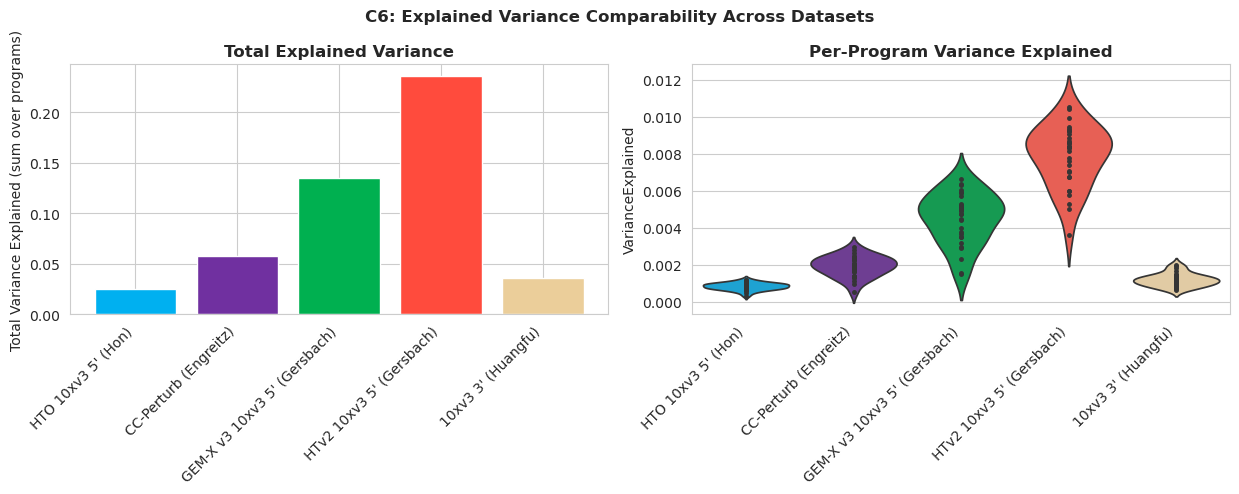

Figure C6 saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(5 + 1.5 * n_datasets, 5))

# Panel A: total variance explained (summed over all k programs) per dataset
sum_var = [all_var_summary[name]["Sum"] for name in dataset_names]
axes[0].bar(dataset_names, sum_var, color=[COLOR_MAP[n] for n in dataset_names])
axes[0].set_ylabel("Total Variance Explained (sum over programs)")
axes[0].set_title("Total Explained Variance", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)
for tick_label in axes[0].get_xticklabels():
    tick_label.set_ha("right")

# Panel B: distribution of per-program variance explained per dataset
var_records = [
    {"dataset": name, "VarianceExplained": v}
    for name in dataset_names
    for v in all_var[name].values
]
var_df = pd.DataFrame(var_records)
sns.violinplot(data=var_df, x="dataset", y="VarianceExplained", ax=axes[1],
               palette=COLOR_MAP, inner="point")
axes[1].set_title("Per-Program Variance Explained", fontweight="bold")
axes[1].set_xlabel(None)
axes[1].tick_params(axis="x", rotation=45)
for tick_label in axes[1].get_xticklabels():
    tick_label.set_ha("right")

fig.suptitle("C6: Explained Variance Comparability Across Datasets", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "C6_explained_variance_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure C6 saved.")

## Figure C3: TF -> Program Perturbation Effects
Rows = TFs shared across all 5 datasets. Columns = programs, aligned to `ref_name` by reciprocal best match (`match_programs_by_overlap`, shared top-`N_TOP_GENES_OVERLAP`-gene count — not cosine similarity). X-axis ordered by match quality (avg shared-gene count with matched program across the other 4 datasets, descending). Values = log2FC. Panel titles colored per `PALETTE`.

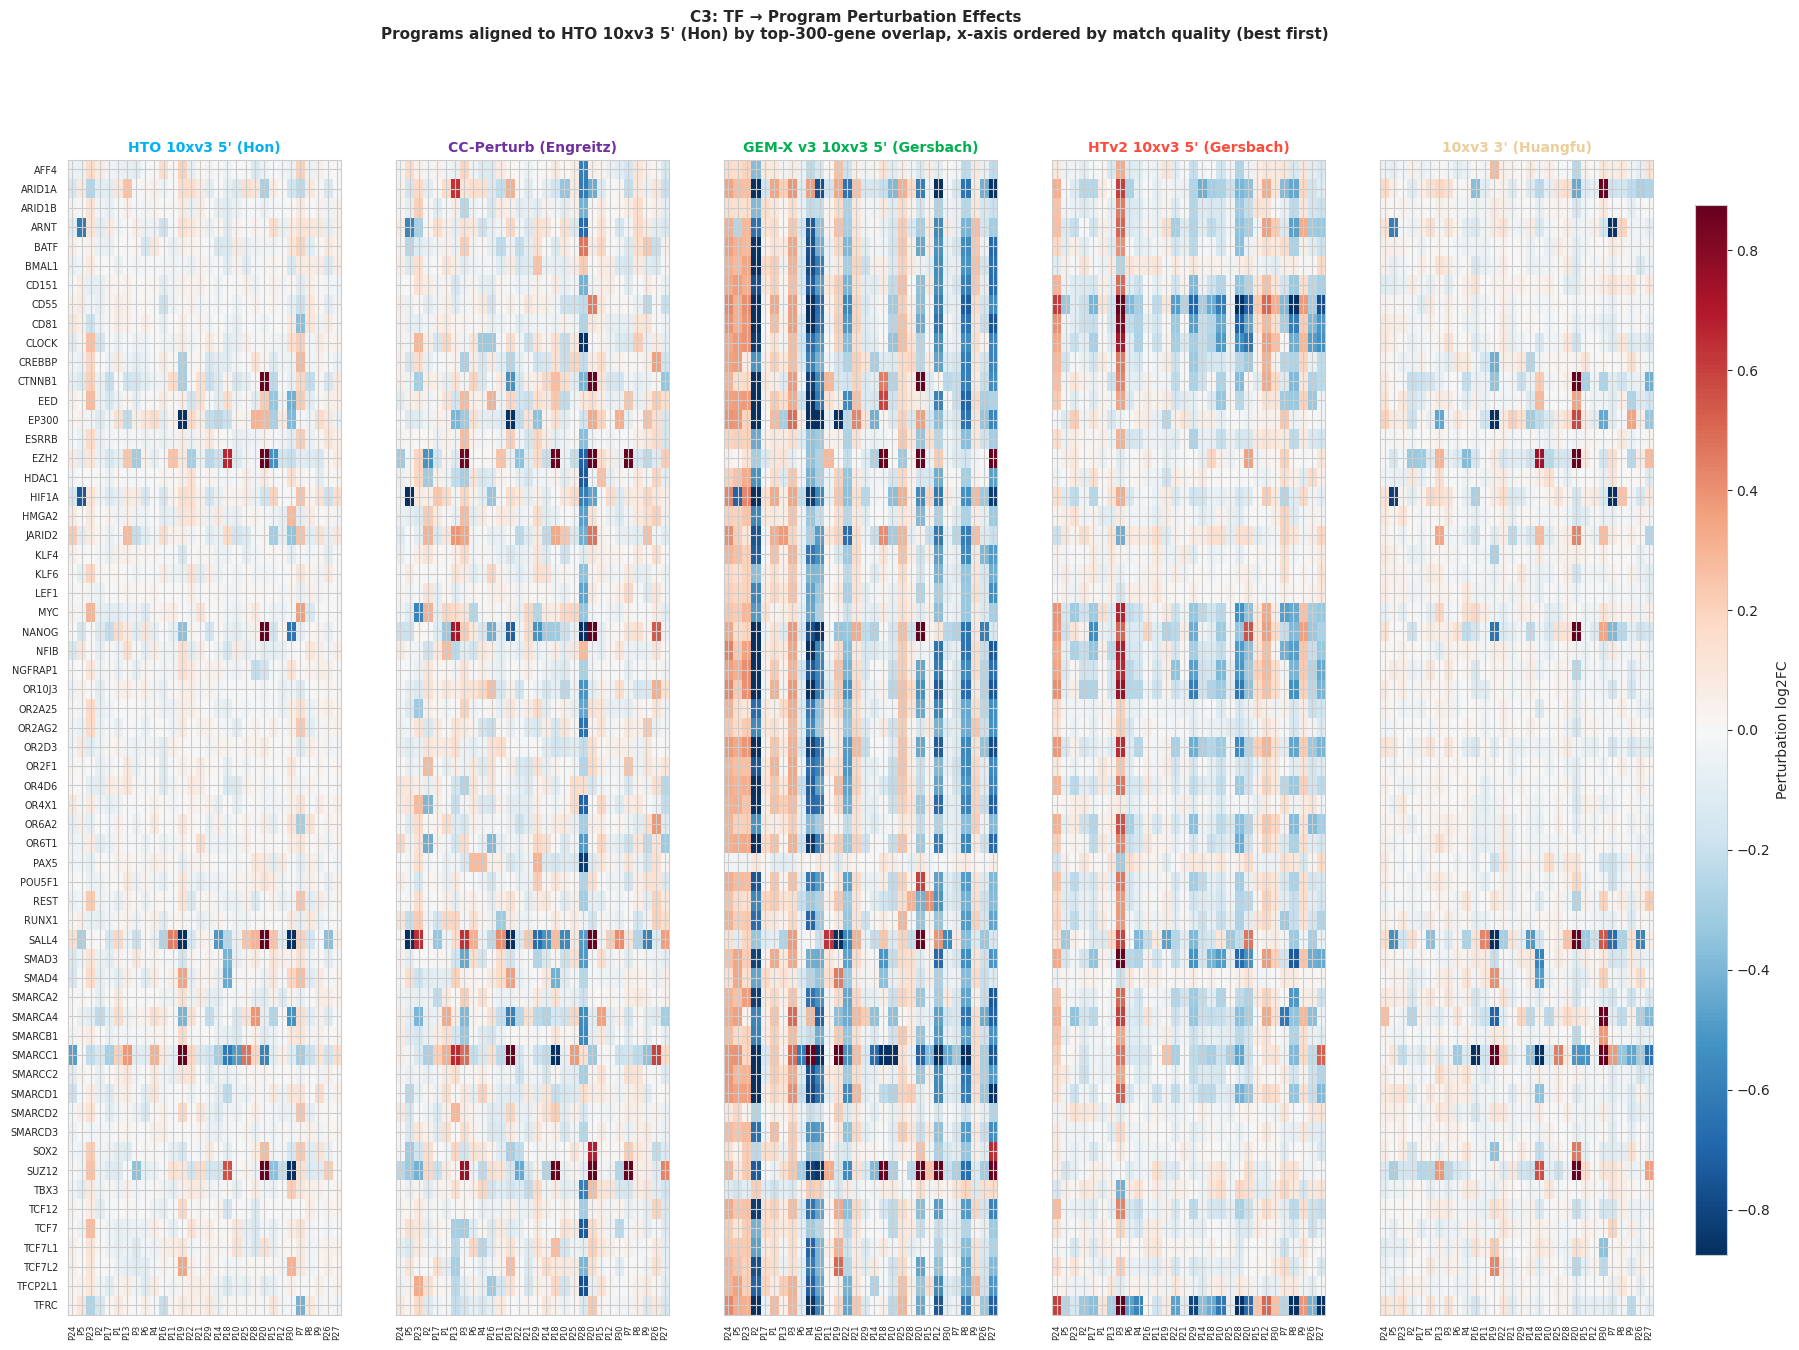

Figure C3 saved.


In [14]:
shared_tfs = sorted(
    set.intersection(*[set(df["target_name"].unique()) for df in all_assoc.values()])
)

ref_name   = dataset_names[0]
n_programs = all_spectra[ref_name].shape[0]

ds_mappings     = {}
ds_match_scores = {}
for ds_name in dataset_names[1:]:
    _, b_to_a, match_scores = match_programs_by_overlap(all_spectra[ref_name], all_spectra[ds_name])
    ds_mappings[ds_name]     = b_to_a
    ds_match_scores[ds_name] = match_scores

# x-axis order: descending avg shared-gene count with matched program across other datasets.
quality_sum = np.zeros(n_programs)
for ds_name in dataset_names[1:]:
    b_to_a = ds_mappings[ds_name]
    scores = ds_match_scores[ds_name]
    a_to_b = np.full(n_programs, -1, dtype=int)
    for b_idx, a_idx in enumerate(b_to_a):
        if 0 <= a_idx < n_programs:
            a_to_b[a_idx] = b_idx
    for i in range(n_programs):
        if a_to_b[i] >= 0:
            quality_sum[i] += scores[a_to_b[i]]
program_order = np.argsort(quality_sum)[::-1]   # descending match quality


def build_tf_program_matrix(ds_name):
    assoc = all_assoc[ds_name]
    mat = np.full((len(shared_tfs), n_programs), np.nan)

    for tf_idx, tf in enumerate(shared_tfs):
        tf_df = assoc.loc[assoc["target_name"] == tf]
        effect = np.full(n_programs, np.nan)
        for _, row in tf_df.iterrows():
            prog = program_name_to_idx(row["program_name"], n_programs)
            effect[prog] = row["log2FC"]

        if ds_name == ref_name:
            mat[tf_idx] = effect
        else:
            b_to_a = ds_mappings[ds_name]
            a_to_b = np.full(n_programs, -1, dtype=int)
            for b_idx, a_idx in enumerate(b_to_a):
                if 0 <= a_idx < n_programs:
                    a_to_b[a_idx] = b_idx
            aligned = np.array([
                effect[a_to_b[i]] if a_to_b[i] >= 0 else np.nan
                for i in range(n_programs)
            ])
            mat[tf_idx] = aligned

    return mat


fig, axes = plt.subplots(
    1, n_datasets,
    figsize=(4 * n_datasets + 1, max(6, 0.25 * len(shared_tfs))),
    sharey=True, squeeze=False,
)

aligned_mats = {}
all_vals = []
for ds_name in dataset_names:
    mat = build_tf_program_matrix(ds_name)
    aligned_mats[ds_name] = mat
    all_vals.extend(mat[np.isfinite(mat)])

vmax = np.nanpercentile(np.abs(all_vals), 99)

for idx, ds_name in enumerate(dataset_names):
    ax = axes[0, idx]
    mat_ordered = aligned_mats[ds_name][:, program_order]
    im = ax.imshow(mat_ordered, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, interpolation="nearest")
    ax.set_title(ds_name, fontsize=10, fontweight="bold", color=COLOR_MAP[ds_name])
    ax.set_xticks(range(n_programs))
    ax.set_xticklabels([f"P{p+1}" for p in program_order], rotation=90, fontsize=6)
    if idx == 0:
        ax.set_yticks(range(len(shared_tfs)))
        ax.set_yticklabels(shared_tfs, fontsize=7)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Perturbation log2FC")
fig.suptitle(f"C3: TF → Program Perturbation Effects\n"
             f"Programs aligned to {ref_name} by top-{N_TOP_GENES_OVERLAP}-gene overlap, "
             "x-axis ordered by match quality (best first)",
             fontsize=11, fontweight="bold")

fig.savefig(os.path.join(OUT_DIR, "C3_tf_program_log2fc_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure C3 saved.")

In [15]:
print("n_programs (from spectra):", n_programs)
print("len(shared_tfs):", len(shared_tfs))
print()

for name in dataset_names:
    pn = all_assoc[name]["program_name"]
    u = sorted(pn.unique())
    print(f"{name}: dtype={pn.dtype}, n_unique={len(u)}, min={u[0]}, max={u[-1]}")
    print(f"  first 5: {u[:5]}  last 5: {u[-5:]}")

print()
tf = shared_tfs[0]
for name in dataset_names:
    df = all_assoc[name]
    tf_df = df.loc[df["target_name"] == tf]
    print(f"{name}: rows for TF={tf!r}: {len(tf_df)}")
    if len(tf_df):
        print(tf_df[["target_name", "program_name", "log2FC"]].head(3).to_string())

print()
for name in dataset_names:
    mat = aligned_mats[name]
    print(f"{name}: finite entries = {np.isfinite(mat).sum()} / {mat.size}")

n_programs (from spectra): 30
len(shared_tfs): 60

HTO 10xv3 5' (Hon): dtype=int64, n_unique=30, min=1, max=30
  first 5: [1, 2, 3, 4, 5]  last 5: [26, 27, 28, 29, 30]
CC-Perturb (Engreitz): dtype=int64, n_unique=30, min=1, max=30
  first 5: [1, 2, 3, 4, 5]  last 5: [26, 27, 28, 29, 30]
GEM-X v3 10xv3 5' (Gersbach): dtype=int64, n_unique=30, min=1, max=30
  first 5: [1, 2, 3, 4, 5]  last 5: [26, 27, 28, 29, 30]
HTv2 10xv3 5' (Gersbach): dtype=int64, n_unique=30, min=1, max=30
  first 5: [1, 2, 3, 4, 5]  last 5: [26, 27, 28, 29, 30]
10xv3 3' (Huangfu): dtype=int64, n_unique=30, min=1, max=30
  first 5: [1, 2, 3, 4, 5]  last 5: [26, 27, 28, 29, 30]

HTO 10xv3 5' (Hon): rows for TF='AFF4': 30
  target_name  program_name    log2FC
0        AFF4             1 -0.048668
1        AFF4             2  0.074081
2        AFF4             3 -0.099099
CC-Perturb (Engreitz): rows for TF='AFF4': 30
  target_name  program_name    log2FC
0        AFF4             1 -0.028925
1        AFF4             2

## Figure C4: Mean Usage of a TF of Interest Across Matched Programs
One column per dataset (colored x-axis labels match `PALETTE`); rows = matched programs; color = mean usage / perturbation effect. Controlled by `TF_OF_INTEREST` in the config cell above.

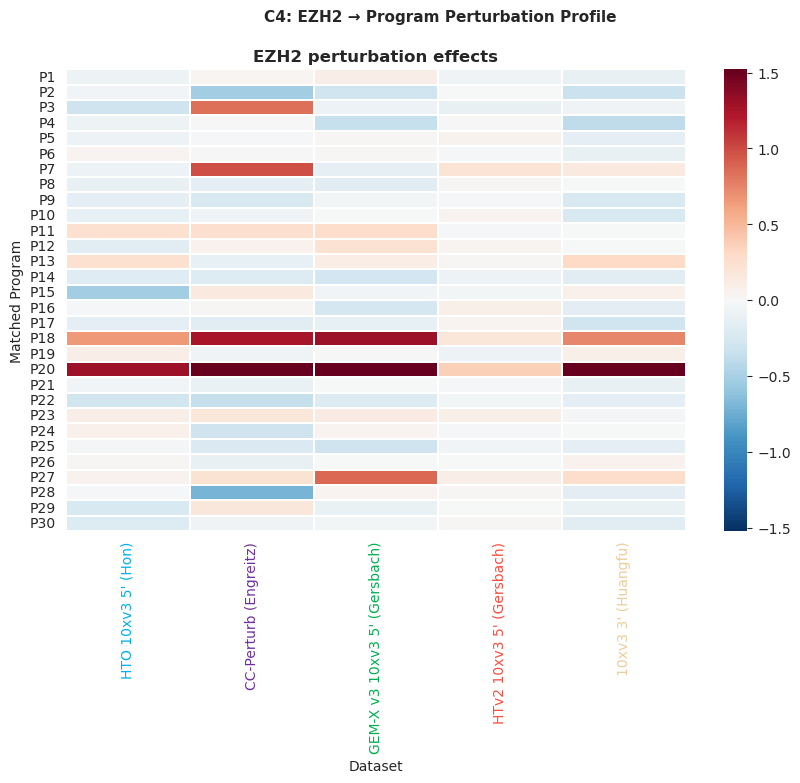

C4 saved for EZH2


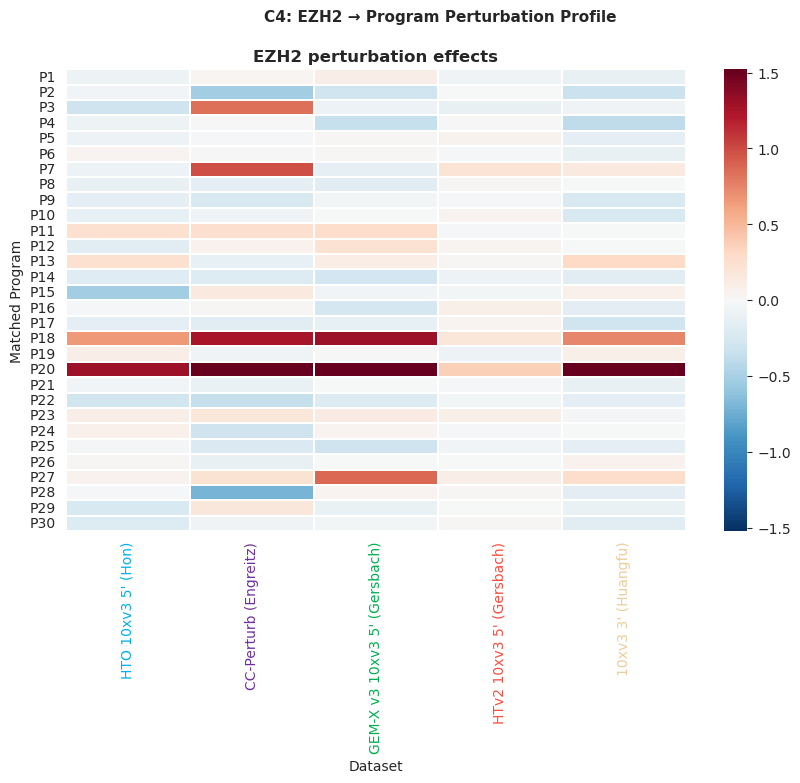

In [16]:
def make_tf_effect_plot(tf_name, dataset_names, all_assoc, all_spectra, ref_name, out_path):
    n_programs = all_spectra[ref_name].shape[0]

    ds_mappings = {}
    for ds_name in dataset_names[1:]:
        _, b_to_a, _ = match_programs_by_overlap(all_spectra[ref_name], all_spectra[ds_name])
        ds_mappings[ds_name] = b_to_a

    effect_vectors = {}
    for ds_name in dataset_names:
        assoc = all_assoc[ds_name]
        tf_df = assoc.loc[assoc["target_name"] == tf_name]
        if len(tf_df) == 0:
            continue

        effect = np.full(n_programs, np.nan)
        for _, row in tf_df.iterrows():
            prog = program_name_to_idx(row["program_name"], n_programs)
            effect[prog] = row["log2FC"]

        if ds_name != ref_name:
            b_to_a = ds_mappings[ds_name]
            a_to_b = np.full(n_programs, -1, dtype=int)
            for b_idx, a_idx in enumerate(b_to_a):
                if 0 <= a_idx < n_programs:
                    a_to_b[a_idx] = b_idx
            effect = np.array([
                effect[a_to_b[i]] if a_to_b[i] >= 0 else np.nan
                for i in range(n_programs)
            ])

        effect_vectors[ds_name] = effect

    if len(effect_vectors) == 0:
        print(f"{tf_name} not found.")
        return None

    effect_df = pd.DataFrame(effect_vectors, index=[f"P{i+1}" for i in range(n_programs)])
    vmax = np.nanpercentile(np.abs(effect_df.values), 99)

    fig, ax = plt.subplots(figsize=(max(4, n_datasets * 2), max(6, n_programs * 0.2)))
    sns.heatmap(effect_df, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
               linewidths=0.25, ax=ax)

    ax.set_title(f"{tf_name} perturbation effects", fontweight="bold")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Matched Program")

    # Color x-tick labels (dataset names) to match PALETTE
    for tick_label in ax.get_xticklabels():
        ds_name = tick_label.get_text()
        if ds_name in COLOR_MAP:
            tick_label.set_color(COLOR_MAP[ds_name])

    fig.suptitle(f"C4: {tf_name} → Program Perturbation Profile", fontsize=11, fontweight="bold")

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"C4 saved for {tf_name}")
    return fig


make_tf_effect_plot(
    tf_name=TF_OF_INTEREST,
    dataset_names=dataset_names,
    all_assoc=all_assoc,
    all_spectra=all_spectra,
    ref_name=dataset_names[0],
    out_path=os.path.join(OUT_DIR, f"C4_{TF_OF_INTEREST}_program_log2fc.png"),
)

## Figure C5: Cross-Dataset TF-Program Perturbation Correlation
For each dataset pair: Spearman correlation of each shared TF's program-level log2FC profile from the pipeline's own perturbation-association test (`all_assoc`/`aligned_mats`, same source as C3/C4/C7 -- not a usage-based statistic), after aligning programs by reciprocal best match. Shows whether the same TFs perturb the same programs, same direction, across datasets. Boxplot; technology-only x-axis labels.

/tmp/ipykernel_1938859/4097959470.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=corr_df, x="pair", y="rho", order=pair_order, palette="Set2", ax=ax)


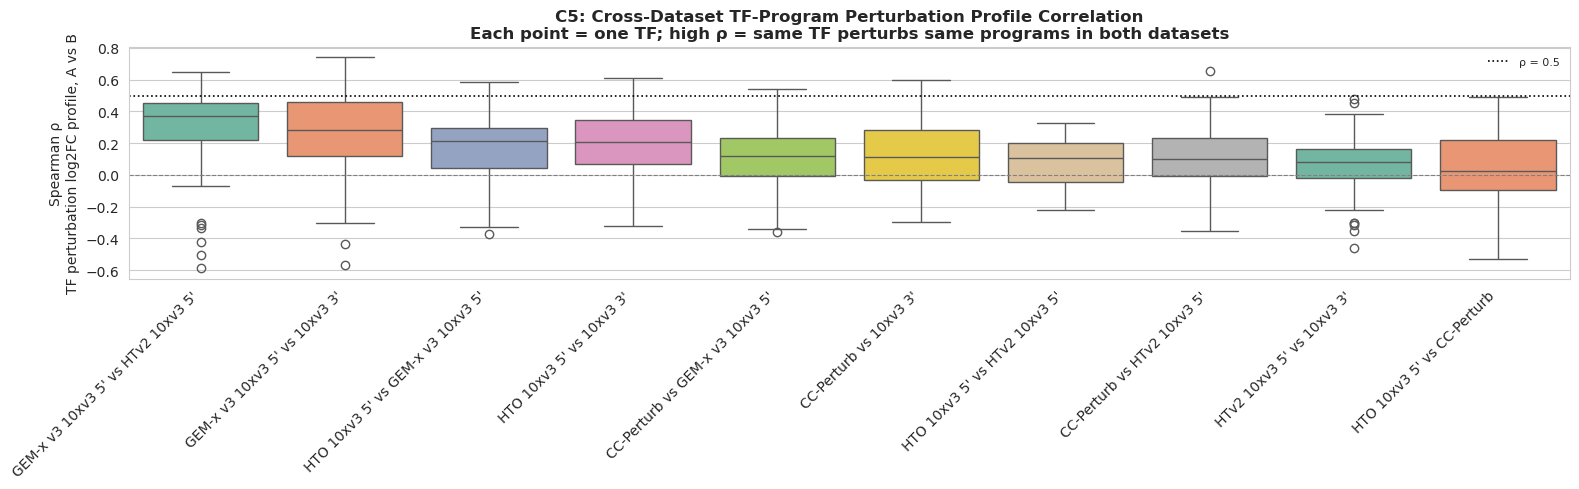

Figure C5 saved.
C5 correlation table saved.


In [17]:
if n_datasets >= 2:
    corr_records = []

    for i in range(n_datasets):
        for j in range(i + 1, n_datasets):
            ds_a, ds_b = dataset_names[i], dataset_names[j]
            pair_label = f"{TECH_LABEL[ds_a]} vs {TECH_LABEL[ds_b]}"

            mat_a = aligned_mats[ds_a]
            mat_b = aligned_mats[ds_b]
            for tf_idx, tf in enumerate(shared_tfs):
                va, vb = mat_a[tf_idx], mat_b[tf_idx]
                mask = np.isfinite(va) & np.isfinite(vb)
                if mask.sum() < 3:
                    continue
                rho, _ = spearmanr(va[mask], vb[mask])
                corr_records.append({"pair": pair_label, "tf": tf, "rho": rho})

    corr_df = pd.DataFrame(corr_records)
    pair_order = (
        corr_df.groupby("pair")["rho"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, ax = plt.subplots(figsize=(max(5, 1.6 * corr_df["pair"].nunique()), 5))
    sns.boxplot(data=corr_df, x="pair", y="rho", order=pair_order, palette="Set2", ax=ax)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=01.2, label="ρ = 0.5")

    #for idx, pair in enumerate(corr_df["pair"].unique()):
    #    med = corr_df.loc[corr_df["pair"] == pair, "rho"].median()
    #    ax.text(idx, med + 0.03, f"{med:.2f}", ha="center", va="bottom",
    #            fontsize=8, fontweight="bold")

    ax.set_xlabel(None)
    ax.set_ylabel("Spearman ρ\nTF perturbation log2FC profile, A vs B")
    ax.set_title("C5: Cross-Dataset TF-Program Perturbation Profile Correlation\n"
                 "Each point = one TF; high ρ = same TF perturbs same programs in both datasets",
                 fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    for tick_label in ax.get_xticklabels():
        tick_label.set_ha("right")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "C5_tf_program_correlation.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure C5 saved.")

    corr_pivot = corr_df.pivot_table(index="tf", columns="pair", values="rho")
    corr_pivot.to_csv(os.path.join(OUT_DIR, "C5_tf_program_correlation_table.csv"))
    print("C5 correlation table saved.")

## Table/Figure C7: Consistent TF Regulators of Matched Programs, Annotated by Enriched Biology
Direct test of "shared programs with shared regulators correspond to established biology": for every (TF, matched-program) pair, keep ones where log2FC (aligned to `ref_name` via C3's matching) is present in >= `MIN_DATASETS_SUPPORT` datasets **and** has a consistent sign.

For the strongest hits:
- **GO terms**: ranked by cross-dataset consistency — each dataset's matched program contributes its own top-`N_GO_PER_DATASET` terms, only terms shared by >= `MIN_GO_DATASETS` datasets shown (`term (n/n_datasets)`).
- **Gene sets / GWAS traits**: still `ref_name`-only (same consistency pass could be added if useful).

In [18]:
# A TF-program pair must have a finite log2FC in at least this many datasets to count as "consistent".
MIN_DATASETS_SUPPORT = 3

consistency_records = []
for tf_idx, tf in enumerate(shared_tfs):
    for prog_idx in range(n_programs):
        vals = np.array([aligned_mats[name][tf_idx, prog_idx] for name in dataset_names])
        finite = vals[np.isfinite(vals)]
        if len(finite) < MIN_DATASETS_SUPPORT:
            continue
        same_sign = np.all(finite > 0) or np.all(finite < 0)
        if not same_sign:
            continue
        consistency_records.append({
            "tf":           tf,
            "program":      f"P{prog_idx + 1}",
            "program_name": prog_idx + 1,
            "n_datasets":   len(finite),
            "mean_log2FC":  finite.mean(),
            "min_log2FC":   finite.min(),
            "max_log2FC":   finite.max(),
        })

consistency_df = pd.DataFrame(consistency_records)
consistency_df["abs_mean_log2FC"] = consistency_df["mean_log2FC"].abs()
consistency_df = consistency_df.sort_values(
    ["n_datasets", "abs_mean_log2FC"], ascending=[False, False]
).reset_index(drop=True)

print(f"{len(consistency_df)} TF-program pairs with a consistent-sign effect in "
      f">= {MIN_DATASETS_SUPPORT}/{n_datasets} datasets (programs aligned to {ref_name}).")
consistency_df.head(20)

250 TF-program pairs with a consistent-sign effect in >= 3/5 datasets (programs aligned to HTO 10xv3 5' (Hon)).


,tf,program,program_name,n_datasets,mean_log2FC,min_log2FC,max_log2FC,abs_mean_log2FC
0,NANOG,P20,20,5,1.568458,0.557059,2.576649,1.568458
1,SALL4,P20,20,5,1.487674,0.469237,1.993106,1.487674
2,SUZ12,P20,20,5,1.434403,0.151855,1.983357,1.434403
3,EZH2,P20,20,5,1.319811,0.361578,1.885710,1.319811
4,SALL4,P19,19,5,-1.250940,-1.752285,-0.471310,1.250940
5,CTNNB1,P20,20,5,1.236086,0.019125,2.108485,1.236086
6,EP300,P19,19,5,-0.863526,-1.281327,-0.250792,0.863526
7,SMARCC1,P19,19,5,0.859783,0.255685,1.130494,0.859783
8,EZH2,P18,18,5,0.827536,0.184685,1.296622,0.827536
9,SMARCC1,P18,18,5,-0.777408,-1.059206,-0.288288,0.777408


In [19]:
N_TOP_HITS       = 15   # how many top consistency_df rows to annotate
N_TOP_TERMS      = 3    # top enriched terms to show per program for genesets/traits (ref_name only)
N_GO_PER_DATASET = 5    # size of each dataset's top-GO-term pool before consistency ranking
MIN_GO_DATASETS  = 2    # a GO term must appear in >= this many datasets' top-N_GO_PER_DATASET to be shown

top_hits = consistency_df.head(N_TOP_HITS).copy()


def format_consistent_go_terms(p):
    hits = consistent_top_terms(all_go, p, dataset_names, ref_name, ds_mappings,
                                 n_per_dataset=N_GO_PER_DATASET, min_datasets=MIN_GO_DATASETS)[:5]
    if not hits:
        return f"(none shared by >= {MIN_GO_DATASETS} datasets' top {N_GO_PER_DATASET})"
    return "; ".join(f"{term} ({n}/{n_datasets})" for term, n in hits)


# GO terms: ranked by how many datasets share them in their top-N_GO_PER_DATASET (not ref_name-only).
top_hits["top_GO_terms"] = top_hits["program_name"].apply(format_consistent_go_terms)

# Gene sets / traits: still ref_name-only (see note in the markdown cell above C7).
top_hits["top_genesets"] = top_hits["program_name"].apply(
    lambda p: "; ".join(top_terms(all_geneset[ref_name], p, n=N_TOP_TERMS))
)
top_hits["top_traits"] = top_hits["program_name"].apply(
    lambda p: "; ".join(top_terms(all_trait[ref_name], p, n=N_TOP_TERMS))
)

out_csv = os.path.join(OUT_DIR, "C7_consistent_tf_program_biology_summary.csv")
top_hits.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

top_hits[["tf", "program", "n_datasets", "mean_log2FC",
          "top_GO_terms", "top_genesets", "top_traits"]]

Saved /hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_cnmf_alex/C7_consistent_tf_program_biology_summary.csv


,tf,program,n_datasets,mean_log2FC,top_GO_terms,top_genesets,top_traits
0,NANOG,P20,5,1.568458,Supramolecular Fiber Organization (GO:0097435)...,Extracellular Matrix Organization R-HSA-147424...,EFO_0004464; EFO_0010736; EFO_0004840
1,SALL4,P20,5,1.487674,Supramolecular Fiber Organization (GO:0097435)...,Extracellular Matrix Organization R-HSA-147424...,EFO_0004464; EFO_0010736; EFO_0004840
2,SUZ12,P20,5,1.434403,Supramolecular Fiber Organization (GO:0097435)...,Extracellular Matrix Organization R-HSA-147424...,EFO_0004464; EFO_0010736; EFO_0004840
3,EZH2,P20,5,1.319811,Supramolecular Fiber Organization (GO:0097435)...,Extracellular Matrix Organization R-HSA-147424...,EFO_0004464; EFO_0010736; EFO_0004840
4,SALL4,P19,5,-1.250940,Nervous System Development (GO:0007399) (3/5);...,Non-integrin membrane-ECM Interactions R-HSA-3...,EFO_0006940; EFO_0004682; EFO_0004725
5,CTNNB1,P20,5,1.236086,Supramolecular Fiber Organization (GO:0097435)...,Extracellular Matrix Organization R-HSA-147424...,EFO_0004464; EFO_0010736; EFO_0004840
6,EP300,P19,5,-0.863526,Nervous System Development (GO:0007399) (3/5);...,Non-integrin membrane-ECM Interactions R-HSA-3...,EFO_0006940; EFO_0004682; EFO_0004725
7,SMARCC1,P19,5,0.859783,Nervous System Development (GO:0007399) (3/5);...,Non-integrin membrane-ECM Interactions R-HSA-3...,EFO_0006940; EFO_0004682; EFO_0004725
8,EZH2,P18,5,0.827536,Transmembrane Receptor Protein Serine/Threonin...,Nervous System Development R-HSA-9675108; Axon...,EFO_0005213; EFO_0004464; EFO_0004840
9,SMARCC1,P18,5,-0.777408,Transmembrane Receptor Protein Serine/Threonin...,Nervous System Development R-HSA-9675108; Axon...,EFO_0005213; EFO_0004464; EFO_0004840


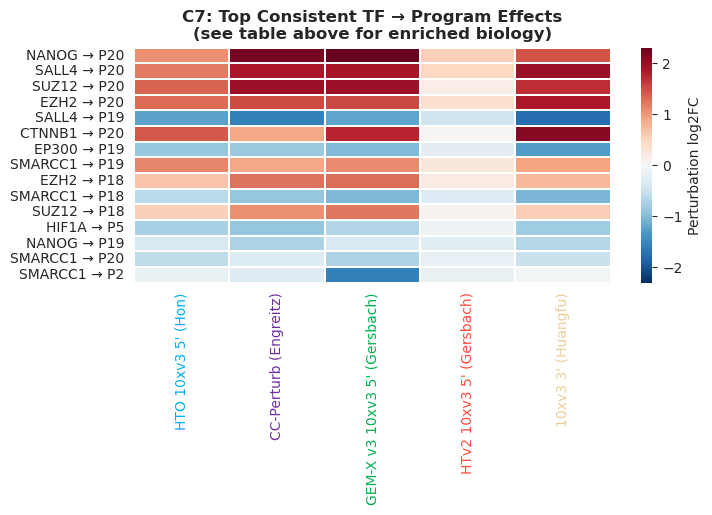

Figure C7 heatmap saved.


In [20]:
heat_rows, row_labels = [], []
for _, r in top_hits.iterrows():
    tf_idx   = shared_tfs.index(r["tf"])
    prog_idx = r["program_name"] - 1
    heat_rows.append([aligned_mats[name][tf_idx, prog_idx] for name in dataset_names])
    row_labels.append(f"{r['tf']} → {r['program']}")

heat_df = pd.DataFrame(heat_rows, index=row_labels, columns=dataset_names)
vmax = np.nanpercentile(np.abs(heat_df.values), 99)

fig, ax = plt.subplots(figsize=(max(6, n_datasets * 1.5), max(4, 0.35 * len(heat_df))))
sns.heatmap(heat_df, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.3, ax=ax, cbar_kws={"label": "Perturbation log2FC"})
ax.set_title("C7: Top Consistent TF → Program Effects\n(see table above for enriched biology)",
             fontweight="bold")
for tick_label in ax.get_xticklabels():
    ds_name = tick_label.get_text()
    if ds_name in COLOR_MAP:
        tick_label.set_color(COLOR_MAP[ds_name])
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "C7_consistent_tf_program_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure C7 heatmap saved.")

## Paper Figure: Program Comparability & Conserved TF-Program Biology (A/B/C)
3-panel composite, reusing data already computed above. Panels A/B use single-line, technology-only x-axis labels (`Tech1 vs Tech2`), ordered high-to-low by median:
- **(A)** Gene-identity comparability: best (max) shared-gene count per program against any program in each other dataset (row-max of C8), per dataset pair.
- **(B)** Raw co-usage view: Spearman ρ of TF-program *usage* profiles (mean cNMF usage per TF's cells, from `all_tf_usage`/h5mu), independent of perturbation log2FC — kept separate from C5, which now uses the pipeline's own log2FC test.
- **(C)** Conserved biology: heatmap of the most cross-dataset-consistent TF → program log2FC effects (same rows as C7/`heat_df`), plain `TF → P#` labels, larger tick labels for print.

/tmp/ipykernel_1938859/1986230923.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=overlap_df, x="pair", y="max_overlap", order=order_a,
/tmp/ipykernel_1938859/1986230923.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=usage_corr_df, x="pair", y="rho", order=order_b,


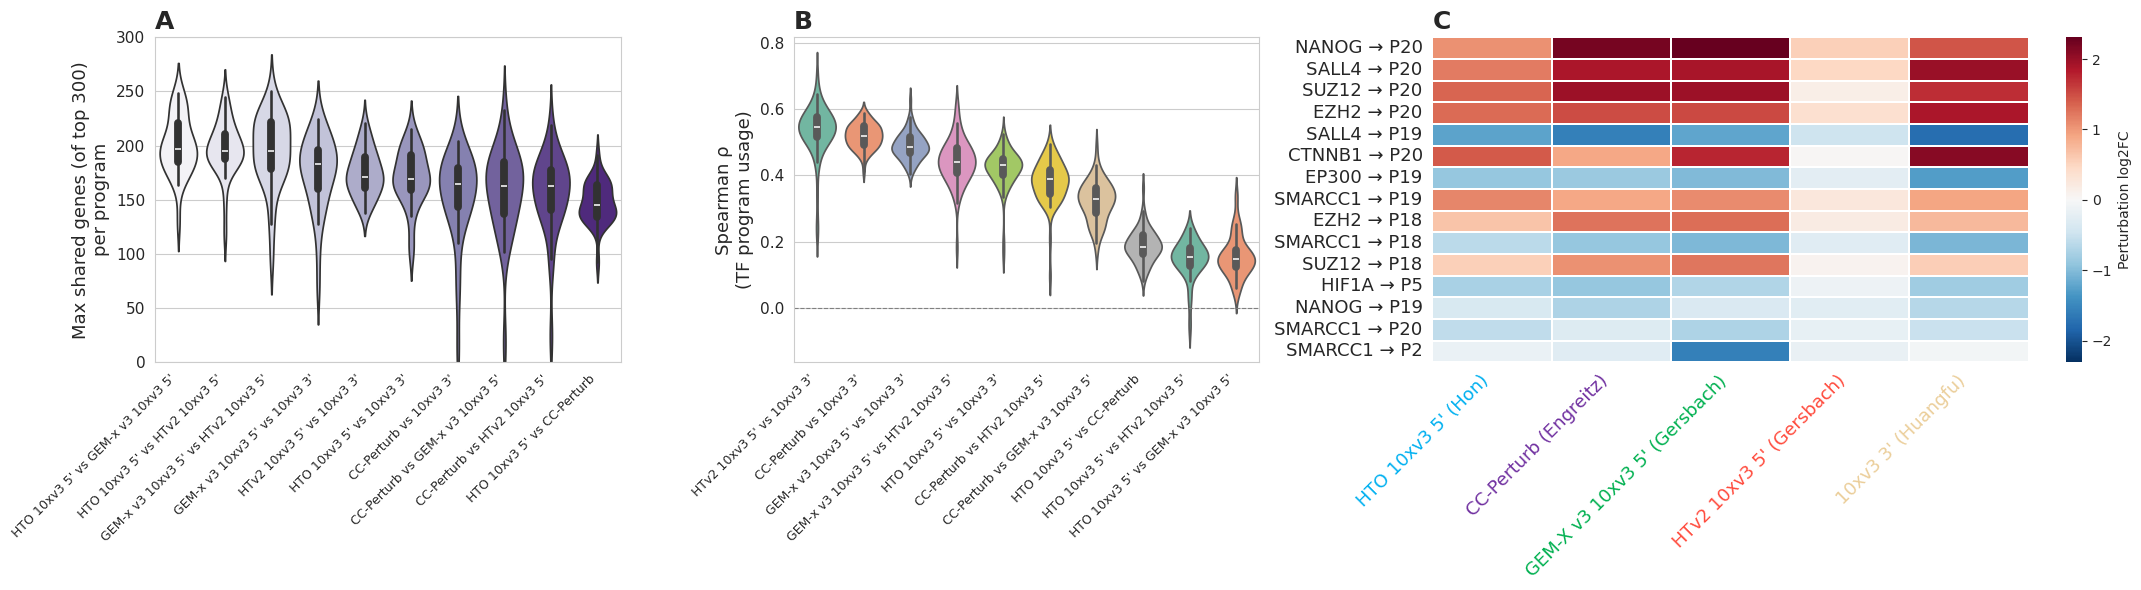

Paper figure (A/B/C) saved.


In [21]:
fig = plt.figure(figsize=(22, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.6])

# --- (A) Max top-N_TOP_GENES_OVERLAP shared-gene count per program, across dataset pairs ---
ax_a = fig.add_subplot(gs[0])
overlap_records = [
    {"pair": f"{TECH_LABEL[ds_a]} vs {TECH_LABEL[ds_b]}", "max_overlap": v}
    for (ds_a, ds_b), mat in gene_overlap_mats.items()
    for v in mat.max(axis=1)
]
overlap_df = pd.DataFrame(overlap_records)
order_a = (overlap_df.groupby("pair")["max_overlap"].median()
           .sort_values(ascending=False).index.tolist())
sns.violinplot(data=overlap_df, x="pair", y="max_overlap", order=order_a,
               palette="Purples", inner="box", ax=ax_a)
ax_a.set_xlabel(None)
ax_a.set_ylabel(f"Max shared genes (of top {N_TOP_GENES_OVERLAP})\nper program", fontsize=13)
ax_a.set_ylim(0, N_TOP_GENES_OVERLAP)
ax_a.set_title("A", fontsize=18, fontweight="bold", loc="left")
ax_a.tick_params(axis="x", rotation=45, labelsize=9)
ax_a.tick_params(axis="y", labelsize=11)
for tick_label in ax_a.get_xticklabels():
    tick_label.set_ha("right")

# --- (B) Spearman rho of TF-program USAGE profiles (raw co-usage; independent of
# perturbation log2FC -- kept separate from C5, which now uses the pipeline's own
# log2FC test) ---
ax_b = fig.add_subplot(gs[1])

ds_mappings_usage = {}
for ds_name in dataset_names[1:]:
    _, b_to_a, _ = match_programs_by_overlap(all_spectra[ref_name], all_spectra[ds_name])
    ds_mappings_usage[ds_name] = b_to_a


def get_aligned_usage_vec(ds_name, tf_name):
    if tf_name not in all_tf_usage[ds_name].index:
        return None
    raw = all_tf_usage[ds_name].loc[tf_name].values
    if ds_name == ref_name:
        return raw
    b_to_a = ds_mappings_usage[ds_name]
    a_to_b = np.full(n_programs, -1, dtype=int)
    for j, a_i in enumerate(b_to_a):
        if 0 <= a_i < n_programs:
            a_to_b[a_i] = j
    return np.array([raw[a_to_b[i]] if a_to_b[i] >= 0 else np.nan for i in range(n_programs)])


usage_corr_records = []
for i in range(n_datasets):
    for j in range(i + 1, n_datasets):
        ds_a, ds_b = dataset_names[i], dataset_names[j]
        pair_label = f"{TECH_LABEL[ds_a]} vs {TECH_LABEL[ds_b]}"
        for tf in shared_tfs:
            va = get_aligned_usage_vec(ds_a, tf)
            vb = get_aligned_usage_vec(ds_b, tf)
            if va is None or vb is None:
                continue
            mask = ~(np.isnan(va) | np.isnan(vb))
            if mask.sum() < 3:
                continue
            rho, _ = spearmanr(va[mask], vb[mask])
            usage_corr_records.append({"pair": pair_label, "tf": tf, "rho": rho})
usage_corr_df = pd.DataFrame(usage_corr_records)

order_b = (usage_corr_df.groupby("pair")["rho"].median()
           .sort_values(ascending=False).index.tolist())
sns.violinplot(data=usage_corr_df, x="pair", y="rho", order=order_b,
               palette="Set2", inner="box", ax=ax_b)
ax_b.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax_b.set_xlabel(None)
ax_b.set_ylabel("Spearman ρ\n(TF program usage)", fontsize=13)
ax_b.set_title("B", fontsize=18, fontweight="bold", loc="left")
ax_b.tick_params(axis="x", rotation=45, labelsize=9)
ax_b.tick_params(axis="y", labelsize=11)
for tick_label in ax_b.get_xticklabels():
    tick_label.set_ha("right")

# --- (C) Most conserved TF -> program perturbation effects ---
ax_c = fig.add_subplot(gs[2])
vmax_c = np.nanpercentile(np.abs(heat_df.values), 99)
sns.heatmap(heat_df, cmap="RdBu_r", center=0, vmin=-vmax_c, vmax=vmax_c,
            linewidths=0.3, ax=ax_c, cbar_kws={"label": "Perturbation log2FC"})
ax_c.set_title("C", fontsize=18, fontweight="bold", loc="left")
ax_c.set_xticklabels(ax_c.get_xticklabels(), fontsize=13, rotation=45, ha="right")
ax_c.set_yticklabels(ax_c.get_yticklabels(), fontsize=13)
for tick_label in ax_c.get_xticklabels():
    ds_name = tick_label.get_text()
    if ds_name in COLOR_MAP:
        tick_label.set_color(COLOR_MAP[ds_name])

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "Paper_Figure_ABC.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "Paper_Figure_ABC.svg"), bbox_inches="tight")
plt.show()
print("Paper figure (A/B/C) saved.")

All figures are also saved as PNGs (C5's and C7's tables as CSVs; the paper figure also as SVG) to `OUT_DIR`:
```
/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_cnmf_alex
```